# CALIMA Dust Analysis — G8 / G9 / G10 Comparison
Post-processing of RAMSES CALIMA simulations at t = 400 Myr.

| Sim | Type | Z | Region |
|-----|------|---|--------|
| G8  | Dwarf galaxy | ~0.03 Z☉ | 5 kpc sphere |
| G9  | Intermediate galaxy | ~0.1 Z☉ | 10 kpc sphere |
| G10 | MW-mass galaxy | ~1 Z☉ | 15 kpc cube |

**Grid strategy:** IC_sim uses a per-sim 2D (T, nH) grid at the sim's mean Z and σ. IC_dtmini and IC_rr14 use a shared 4D (T, nH, Z, σ) grid with per-cell Z and σ from the RAMSES fields.

In [1]:
import sys, os, json, time, copy
import numpy as np
import matplotlib; matplotlib.rcParams.update({'figure.dpi': 120, 'text.usetex': False})
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

PYCALIMA = os.path.expanduser('~/Documents/GitHub/pyCALIMA')
sys.path.insert(0, PYCALIMA)
os.chdir(PYCALIMA)

import yt; yt.set_log_level('critical')
from solvers.run_grid import run_grid

# ── Physical constants ────────────────────────────────────────────────────────
MH         = 1.6726e-24
MU         = 1.4
ZSUN       = 0.0134
SioverSil  = 0.163
T_SIM_MYR  = 399.6
UNIT_V_KMS = 65.59

ZUBKO_FRACS = np.array([0.071933, 0.253672, 0.104929, 0.569437])
BIN_NAMES  = ['SmCarb (0.005µm)', 'LgCarb (0.1µm)', 'SmSil (0.005µm)', 'LgSil (0.1µm)']
BIN_SHORT  = ['SmC', 'LgC', 'SmSi', 'LgSi']
BIN_COLORS = ['#e07b39', '#c0392b', '#2980b9', '#1a5276']

# Shared T-nH phase diagram axis limits (same for both sims)
NH_LO, NH_HI = -4.0, 3.0
T_LO,  T_HI  =  1.5, 8.0

# Shared pyCALIMA grid axes (same for both sims for direct comparability)
T_GRID  = np.logspace(1.0, 7.0, 20)
NH_GRID = np.logspace(-3.0, 4.0, 20)

RK4_SOLVER = {'type': 'rk4', 'errmax': 0.1, 'countmax': 200000,
               'h_max_Myr': 20.0, 'h_init_s': 1.0e8}  # used only for t_end sweep (2D, mean Z/sigma)
NK_SOLVER  = {'type': 'newton_krylov', 'f_tol': 1e-300, 'f_rtol': 1e-6,
               'maxiter': 500, 'inner_maxiter': 300}

# Solar metal mass fractions — Asplund+2009 (derived from G10 config at 0.7 Zsun)
SOLAR_METALS = {
    'C':  0.001659/0.7, 'N':  0.0005824/0.7, 'O':  0.004015/0.7,
    'Mg': 0.0004508/0.7,'Si': 0.0004697/0.7, 'S':  0.0002387/0.7,
    'Fe': 0.0008806/0.7,
}
_H0, _He0 = 0.7381, 0.2485   # Asplund+2009 H and He mass fractions at solar Z

OUTDIR = os.path.join(PYCALIMA, 'results', 'comparison')
os.makedirs(OUTDIR, exist_ok=True)

IC_2D = []                    # no per-sim IC (would require knowing current dust state)
IC_4D = ['IC_rr14']               # shared grids, independent of IC
print('Setup complete. Output ->', OUTDIR)

Setup complete. Output -> /Users/currodri/Documents/GitHub/pyCALIMA/results/comparison


## 1. Load Simulations

Load G8 (5 kpc sphere, 0.1 Z☉) and G10 (15 kpc cube, ~1 Z☉) from RAMSES outputs at t = 400 Myr.
Extract T, nH, dust densities per bin, metallicity, and spatial coordinates.

In [2]:
RAMSES_G8  = os.path.expanduser(
    '~/Documents/RAMSES_dev/pyCALIMA_testing/test_outputs'
    '/CorrectSN_0.03Zsun_DTMini1d-3_MR/output_00081')
RAMSES_G9  = os.path.expanduser(
    '~/Documents/RAMSES_dev/pyCALIMA_testing/test_outputs'
    '/CorrectSN_0.1Zsun_DTMini1d-3/output_00081')
RAMSES_G10 = os.path.expanduser(
    '~/Documents/RAMSES_dev/pyCALIMA_testing/test_outputs'
    '/CorrectSN_MR/output_00081')
CONFIG_G8  = os.path.join(PYCALIMA, 'solvers/configs/ramses_G8_0.03Zsun.json')
CONFIG_G9  = os.path.join(PYCALIMA, 'solvers/configs/ramses_G8_0.1Zsun.json')  # G9 is 0.1 Zsun
CONFIG_G10 = os.path.join(PYCALIMA, 'solvers/configs/ramses_G10_MWZsun.json')

def _add_fields(ds):
    ds.add_field(('gas','nH'), sampling_type='cell', force_override=True, units='1/cm**3',
                 function=lambda field,data: (data[('gas','density')]/(MU*yt.units.mh)).to('1/cm**3'))
    ds.add_field(('gas','T_gas'), sampling_type='cell', force_override=True, units='K',
                 function=lambda field,data: data[('gas','temperature')].to('K'))
    ds.add_field(('gas','sigma_turb_kms'), sampling_type='cell', force_override=True, units='km/s',
                 function=lambda field,data: data[('ramses','hydro_scalar_14')] * UNIT_V_KMS * yt.units.km/yt.units.s)
    for k, (bn, corr) in enumerate([('hydro_dust_bin01',1.0),('hydro_dust_bin02',1.0),
                                      ('hydro_dust_bin03',SioverSil),('hydro_dust_bin04',SioverSil)]):
        def _mk(bn=bn, corr=corr):
            return lambda field,data: (data[('ramses',bn)]*data[('gas','density')]/corr).to('g/cm**3')
        ds.add_field(('gas',f'rho_d{k+1}'), units='g/cm**3',
                     sampling_type='cell', force_override=True, function=_mk())
    # Derived dust fraction fields (used for yt projections)
    def _dust_total(field, data):
        return (data[('gas','rho_d1')] + data[('gas','rho_d2')] +
                data[('gas','rho_d3')] + data[('gas','rho_d4')])
    ds.add_field(('gas','dust_total'), units='g/cm**3', sampling_type='cell',
                 force_override=True, function=_dust_total)
    def _proj_DTM(field, data):
        metal = data[('ramses','Metallicity')] * data[('gas','density')]
        dust  = data[('gas','dust_total')]
        return data.ds.arr(np.where(metal.v > 0, dust.v / metal.v, 0.0), 'dimensionless')
    ds.add_field(('gas','proj_DTM'), units='dimensionless', sampling_type='cell',
                 force_override=True, function=_proj_DTM)
    def _proj_DTG(field, data):
        rho  = data[('gas','density')]
        dust = data[('gas','dust_total')]
        return data.ds.arr(np.where(rho.v > 0, dust.v / rho.v, 0.0), 'dimensionless')
    ds.add_field(('gas','proj_DTG'), units='dimensionless', sampling_type='cell',
                 force_override=True, function=_proj_DTG)
    def _proj_f_small(field, data):
        dust  = data[('gas','dust_total')]
        small = data[('gas','rho_d1')] + data[('gas','rho_d3')]
        return data.ds.arr(np.where(dust.v > 0, small.v / dust.v, 0.0), 'dimensionless')
    ds.add_field(('gas','proj_f_small'), units='dimensionless', sampling_type='cell',
                 force_override=True, function=_proj_f_small)
    def _proj_f_carb(field, data):
        dust = data[('gas','dust_total')]
        carb = data[('gas','rho_d1')] + data[('gas','rho_d2')]
        return data.ds.arr(np.where(dust.v > 0, carb.v / dust.v, 0.0), 'dimensionless')
    ds.add_field(('gas','proj_f_carb'), units='dimensionless', sampling_type='cell',
                 force_override=True, function=_proj_f_carb)

def extract_sim(ds, region):
    """Extract all needed arrays from a yt region."""
    T    = region[('gas','T_gas')].v.astype(float)
    nH   = region[('gas','nH')].v.astype(float)
    rho  = region[('gas','density')].to('g/cm**3').v.astype(float)
    vols = region[('index','cell_volume')].to('cm**3').v.astype(float)
    sig  = region[('gas','sigma_turb_kms')].v.astype(float)
    rho_d = np.column_stack([region[('gas',f'rho_d{k+1}')].v.astype(float) for k in range(4)])
    try:
        mf = region[('ramses','Metallicity')].v.astype(float)
    except Exception:
        mf = np.full(len(T), 0.1*ZSUN)
    masses = rho * vols
    # metallicity field = (gas metals + dust) / rho_gas — already includes dust
    rho_metal_tot = mf * rho
    with np.errstate(invalid='ignore', divide='ignore'):
        DTM_bins = np.where(rho_metal_tot[:,None] > 0, rho_d/rho_metal_tot[:,None], np.nan)
    DTM = np.nansum(DTM_bins, axis=1)
    total_dust = rho_d.sum(axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        DTG        = np.where(rho > 0, total_dust/rho, np.nan)
        small_frac = np.where(total_dust > 0, (rho_d[:,0]+rho_d[:,2])/total_dust, np.nan)
        carb_frac  = np.where(total_dust > 0, (rho_d[:,0]+rho_d[:,1])/total_dust, np.nan)
    Z_Zsun = mf / ZSUN
    return dict(T=T, nH=nH, rho=rho, masses=masses, sig=sig,
                rho_d=rho_d, metal_frac=mf, rho_metal_tot=rho_metal_tot,
                DTM_bins=DTM_bins, DTM=DTM, DTG=DTG,
                small_frac=small_frac, carb_frac=carb_frac, Z_Zsun=Z_Zsun)

# ── Load G8 ───────────────────────────────────────────────────────────────────
print('Loading G8 ...')
ds8 = yt.load(RAMSES_G8);  _add_fields(ds8)
cen8 = ds8.domain_center
reg8 = ds8.sphere(cen8, (5.0, 'kpc'))
s8   = extract_sim(ds8, reg8)
s8['label'] = 'G8 (5 kpc sphere, 0.03 Zsun)'
s8['tag']   = 'G8'
s8['config']= CONFIG_G8
x8 = reg8[('index','x')].to('kpc').v - cen8.to('kpc').v[0]
y8 = reg8[('index','y')].to('kpc').v - cen8.to('kpc').v[1]
s8['x_kpc'] = x8;  s8['y_kpc'] = y8;  s8['half_kpc'] = 5.0/2

Z_ZSUN_G8 = np.average(s8['Z_Zsun'], weights=s8['masses'])
s8['Z_ZSUN'] = Z_ZSUN_G8
print(f"G8: {len(s8['T']):,} cells, <Z>={Z_ZSUN_G8:.3f} Zsun, <DTM>={np.average(s8['DTM'],weights=s8['masses']):.4f}")

# ── Load G9 ───────────────────────────────────────────────────────────────────
print('Loading G9 ...')
ds9 = yt.load(RAMSES_G9);  _add_fields(ds9)
cen9 = ds9.domain_center
reg9 = ds9.sphere(cen9, (10.0, 'kpc'))
s9   = extract_sim(ds9, reg9)
s9['label'] = 'G9 (10 kpc sphere, ~0.1 Zsun)'
s9['tag']   = 'G9'
s9['config']= CONFIG_G9
x9 = reg9[('index','x')].to('kpc').v - cen9.to('kpc').v[0]
y9 = reg9[('index','y')].to('kpc').v - cen9.to('kpc').v[1]
s9['x_kpc'] = x9;  s9['y_kpc'] = y9;  s9['half_kpc'] = 5.0

Z_ZSUN_G9 = np.average(s9['Z_Zsun'], weights=s9['masses'])
s9['Z_ZSUN'] = Z_ZSUN_G9
print(f"G9: {len(s9['T']):,} cells, <Z>={Z_ZSUN_G9:.3f} Zsun, <DTM>={np.average(s9['DTM'],weights=s9['masses']):.4f}")

# ── Load G10 ──────────────────────────────────────────────────────────────────
print('Loading G10 ...')
ds10 = yt.load(RAMSES_G10);  _add_fields(ds10)
cen10 = ds10.domain_center
half  = ds10.quan(7.5, 'kpc')
reg10 = ds10.box(cen10 - ds10.arr([half,half,half]), cen10 + ds10.arr([half,half,half]))
s10   = extract_sim(ds10, reg10)
s10['label'] = 'G10 (15 kpc cube, ~1 Zsun)'
s10['tag']   = 'G10'
s10['config']= CONFIG_G10
x10 = reg10[('index','x')].to('kpc').v - cen10.to('kpc').v[0]
y10 = reg10[('index','y')].to('kpc').v - cen10.to('kpc').v[1]
s10['x_kpc'] = x10;  s10['y_kpc'] = y10;  s10['half_kpc'] = 7.5

Z_ZSUN_G10 = np.average(s10['Z_Zsun'], weights=s10['masses'])
s10['Z_ZSUN'] = Z_ZSUN_G10
print(f"G10: {len(s10['T']):,} cells, <Z>={Z_ZSUN_G10:.3f} Zsun, <DTM>={np.average(s10['DTM'],weights=s10['masses']):.4f}")

s8['ds']        = ds8
s8['region']    = reg8
s8['center']    = cen8
s8['width_kpc'] = 5.0

s9['ds']        = ds9
s9['region']    = reg9
s9['center']    = cen9
s9['width_kpc'] = 10.0

s10['ds']        = ds10
s10['region']    = reg10
s10['center']    = cen10
s10['width_kpc'] = 15.0

SIMS = [s8, s9, s10]

Loading G8 ...


/Users/currodri/.pyenv/versions/3.12.8/envs/calima/lib/python3.12/site-packages/unyt/array.py:1900: RuntimeWarning: invalid value encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


G8: 1,110,026 cells, <Z>=0.136 Zsun, <DTM>=0.1400
Loading G9 ...


G9: 3,407,320 cells, <Z>=0.479 Zsun, <DTM>=0.2011
Loading G10 ...


G10: 5,220,540 cells, <Z>=1.030 Zsun, <DTM>=0.3569


## 1b. ISM Distributions

Mass-weighted histograms of temperature, density, metallicity, and turbulent velocity dispersion
for all three simulations overlaid on the same axes.


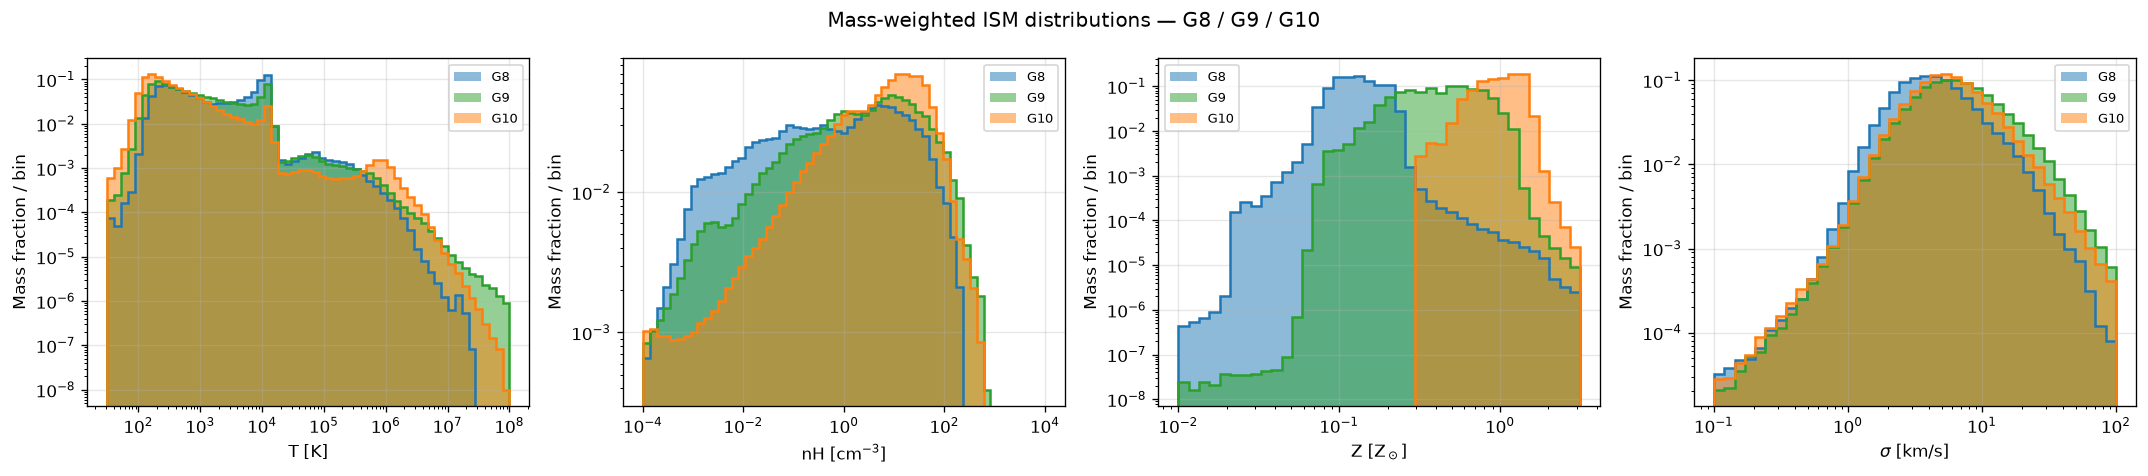

Saved ism_histograms.png


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

QUANTS = [
    ('T',      'T [K]',              np.logspace(1.5, 8,  60), True ),
    ('nH',     'nH [cm$^{-3}$]',    np.logspace(-4,  4,  60), True ),
    ('Z_Zsun', 'Z [Z$_\\odot$]', np.logspace(-2,  0.5, 40), True ),
    ('sig',    '$\\sigma$ [km/s]', np.logspace(-1,  2,  40), True ),
]
SIM_COLORS = ['C0', 'C2', 'C1']   # G8, G9, G10

for ax, (key, xlabel, bins, logx) in zip(axes, QUANTS):
    for sim, clr in zip(SIMS, SIM_COLORS):
        vals    = sim[key]
        masses  = sim['masses']
        ok      = np.isfinite(vals) & (vals > 0) & (masses > 0)
        weights = masses[ok]
        weights = weights / weights.sum()   # normalise to probability
        ax.hist(vals[ok], bins=bins, weights=weights,
                color=clr, alpha=0.5, label=sim['tag'], histtype='stepfilled')
        ax.hist(vals[ok], bins=bins, weights=weights,
                color=clr, alpha=1.0, histtype='step', lw=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mass fraction / bin')
    if logx:
        ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Mass-weighted ISM distributions — G8 / G9 / G10', fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ism_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved ism_histograms.png')


## 2. Phase Diagrams (T–nH plane)

Mass-weighted mean of each quantity in bins of log nH × log T.
Fixed axis ranges: log nH ∈ [−4, 3], log T ∈ [1.5, 8].
Same colour scales for G8 and G10 to enable direct comparison.

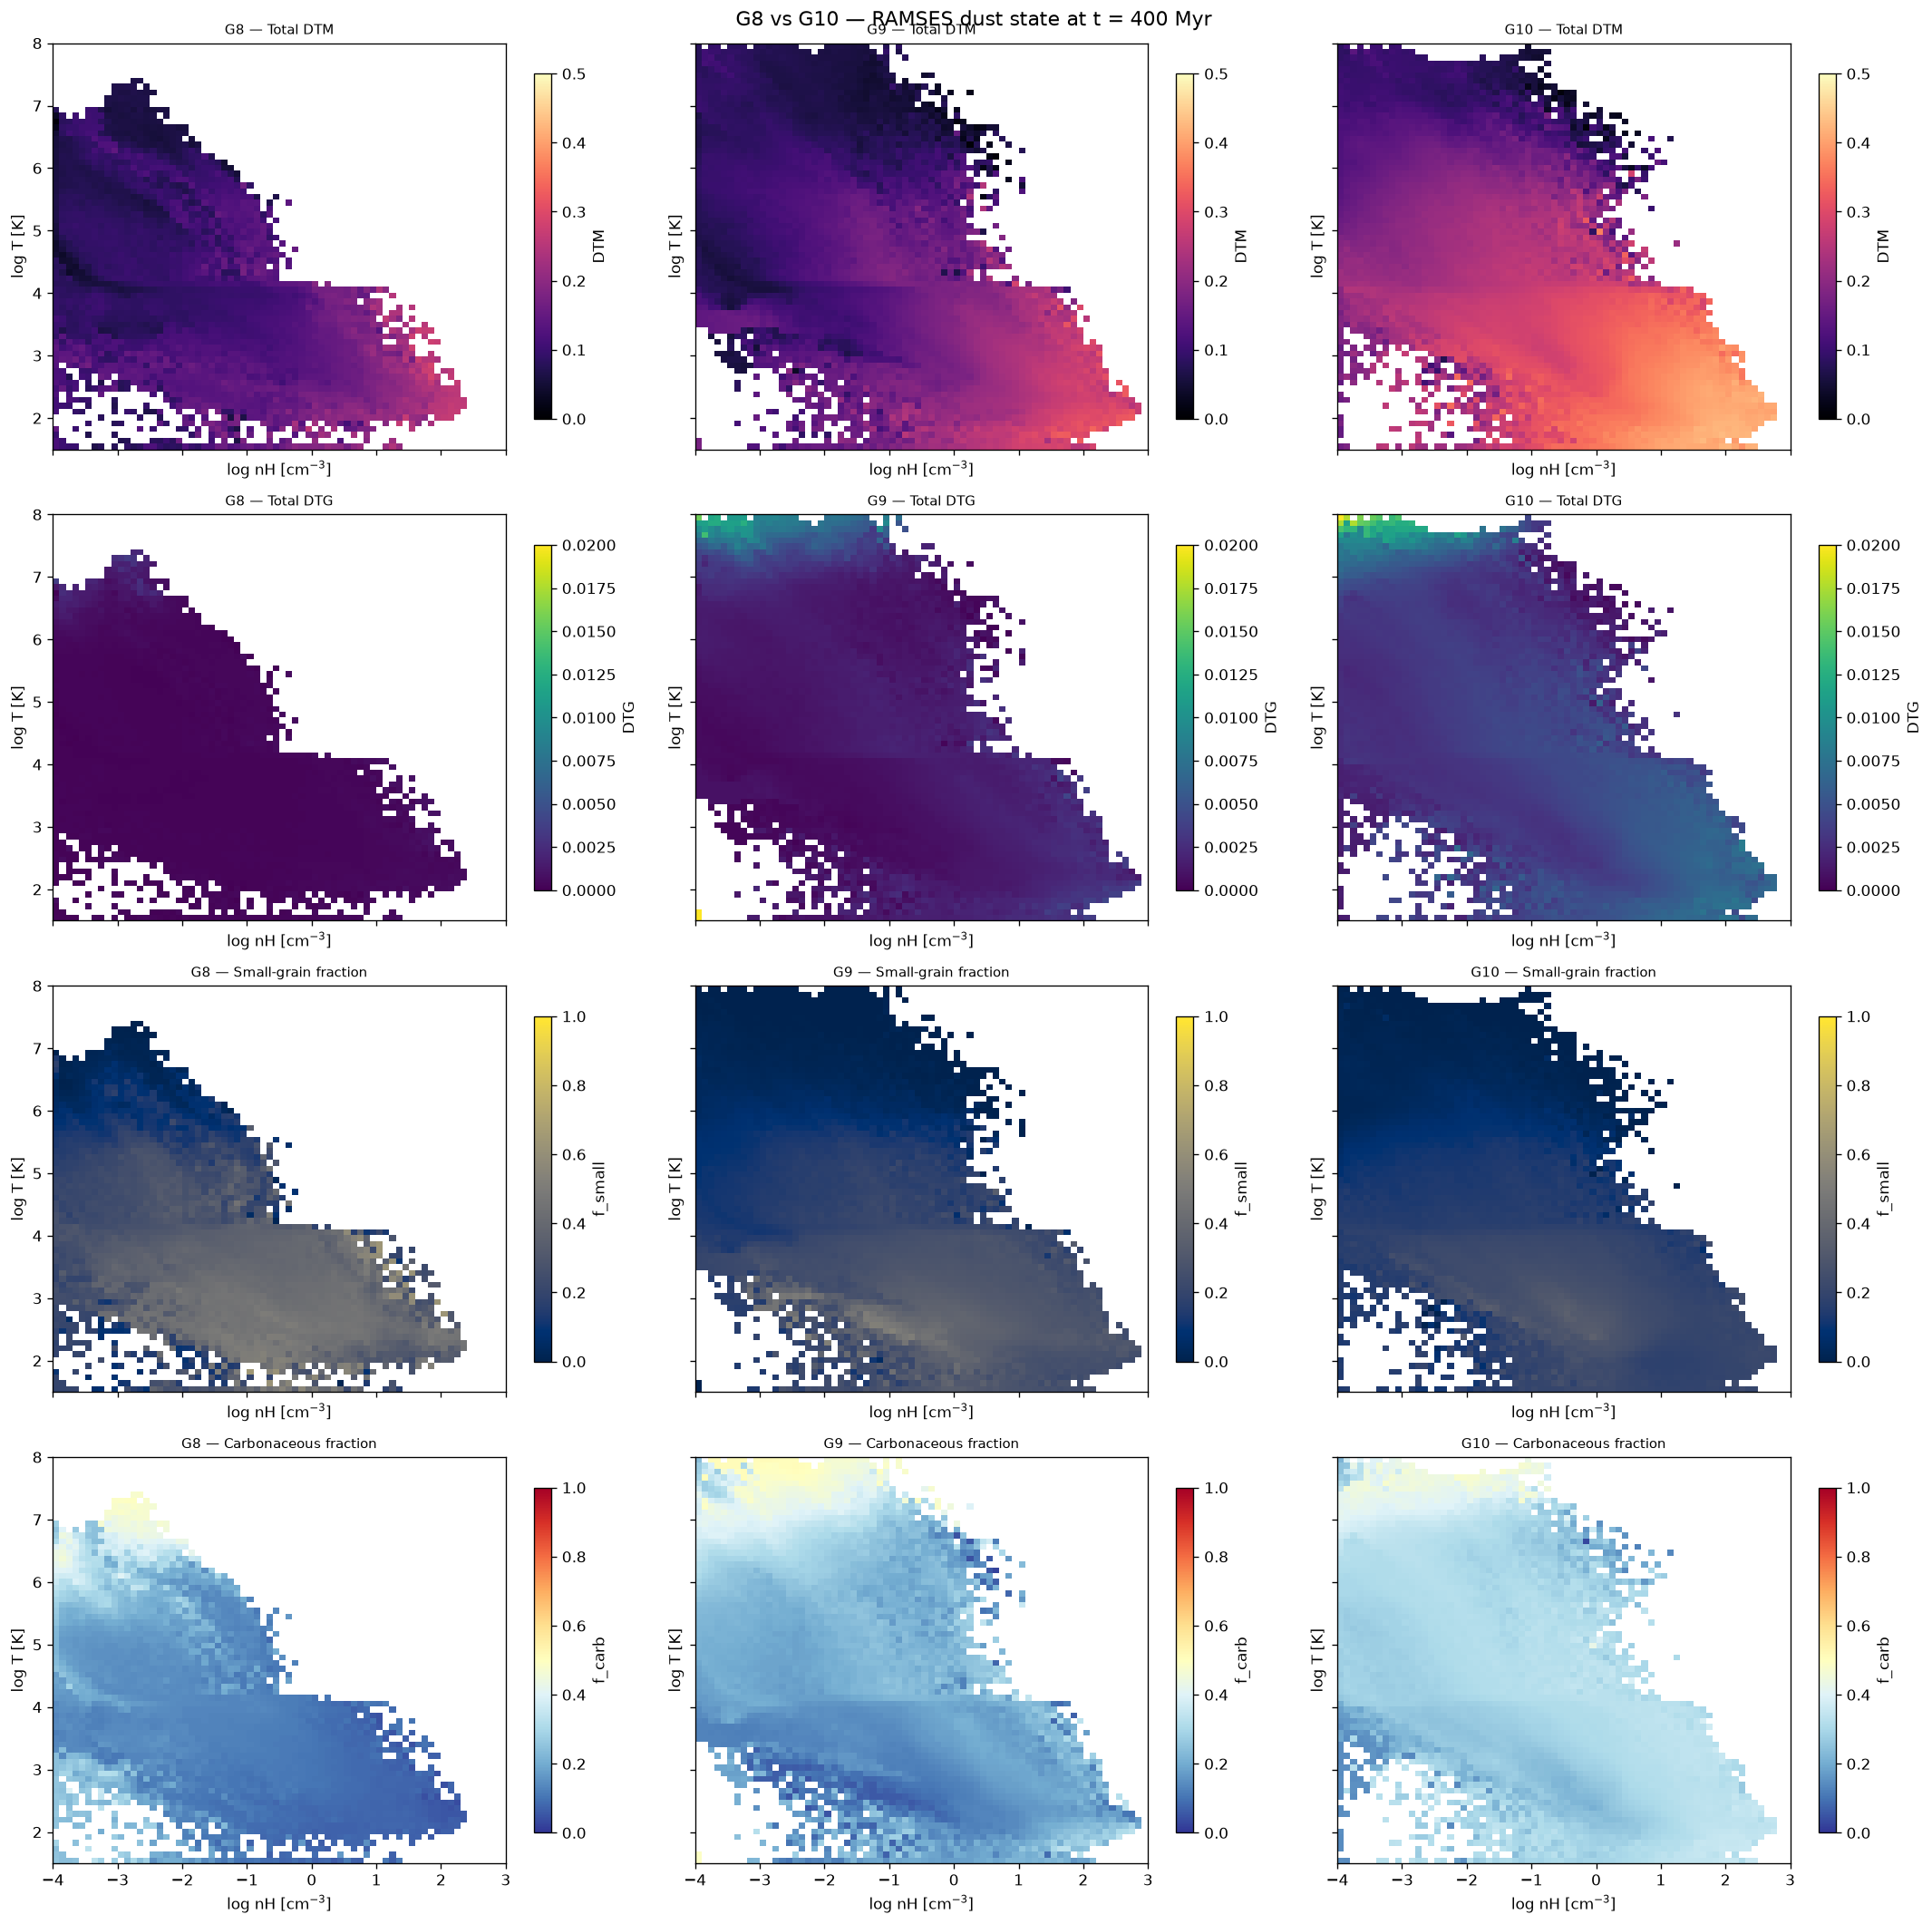

Saved phase_maps.png


In [4]:
def phase_map(ax, nH, T, values, weights, label, cmap='viridis',
              vmin=None, vmax=None, log=True, nH_bins=70, T_bins=70, min_count=1,
              y_lo=None, y_hi=None, y_label='log T [K]'):
    """Mass-weighted phase diagram. nH on x-axis, y-axis variable (default: T).
    Bins with fewer than min_count cells are shown as NaN."""
    if y_lo is None: y_lo = T_LO
    if y_hi is None: y_hi = T_HI
    nH_edges = np.logspace(NH_LO, NH_HI, nH_bins+1)
    T_edges  = np.logspace(y_lo,  y_hi,  T_bins+1)
    nH_c = np.clip(nH, 10**NH_LO, 10**NH_HI)
    T_c  = np.clip(T,  10**y_lo,  10**y_hi)
    log_bins = [np.log10(nH_edges), np.log10(T_edges)]
    cnt,_,_ = np.histogram2d(np.log10(nH_c), np.log10(T_c), bins=log_bins)
    num,_,_ = np.histogram2d(np.log10(nH_c), np.log10(T_c),
                              bins=log_bins, weights=weights*values)
    den,_,_ = np.histogram2d(np.log10(nH_c), np.log10(T_c),
                              bins=log_bins, weights=weights)
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = np.where((den>0) & (cnt>=min_count), num/den, np.nan)
    if log:
        mean = np.log10(np.where(mean>0, mean, np.nan))
    im = ax.pcolormesh(np.log10(nH_edges), np.log10(T_edges),
                       mean.T, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    ax.set_xlabel('log nH [cm$^{-3}$]')
    ax.set_ylabel(y_label)
    ax.set_xlim(NH_LO, NH_HI)
    ax.set_ylim(y_lo, y_hi)
    ax.set_title(label, fontsize=9)
    return im

# Panel definitions: (field_key, title, cmap, vmin, vmax, log_scale)
PANELS = [
    ('DTM',        'Total DTM',            'magma',     0,  0.5,  False),
    ('DTG',        'Total DTG',            'viridis',   0,  0.02, False),
    ('small_frac', 'Small-grain fraction', 'cividis',   0,  1.0,  False),
    ('carb_frac',  'Carbonaceous fraction','RdYlBu_r',  0,  1.0,  False),
]
CLABELS = ['DTM', 'DTG', 'f_small', 'f_carb']

fig, axes = plt.subplots(4, len(SIMS), figsize=(6*len(SIMS), 18), sharex=True, sharey=True)

for row, ((key, ttl, cmap, vmin, vmax, do_log), clbl) in enumerate(zip(PANELS, CLABELS)):
    for col, sim in enumerate(SIMS):
        ax = axes[row, col]
        v  = sim[key]
        m  = np.isfinite(v) & (v > 0) & (sim['masses'] > 0)
        im = phase_map(ax, sim['nH'][m], sim['T'][m], v[m], sim['masses'][m],
                       f"{sim['tag']} — {ttl}", cmap=cmap, vmin=vmin, vmax=vmax, log=do_log)
        plt.colorbar(im, ax=ax, label=clbl, shrink=0.85)

fig.suptitle('G8 vs G10 — RAMSES dust state at t = 400 Myr', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'phase_maps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved phase_maps.png')

## 3. Spatial Projections (z-axis)

Mass-weighted mean projected along the z-axis. G8: 5 kpc diameter, G10: 15 kpc box.

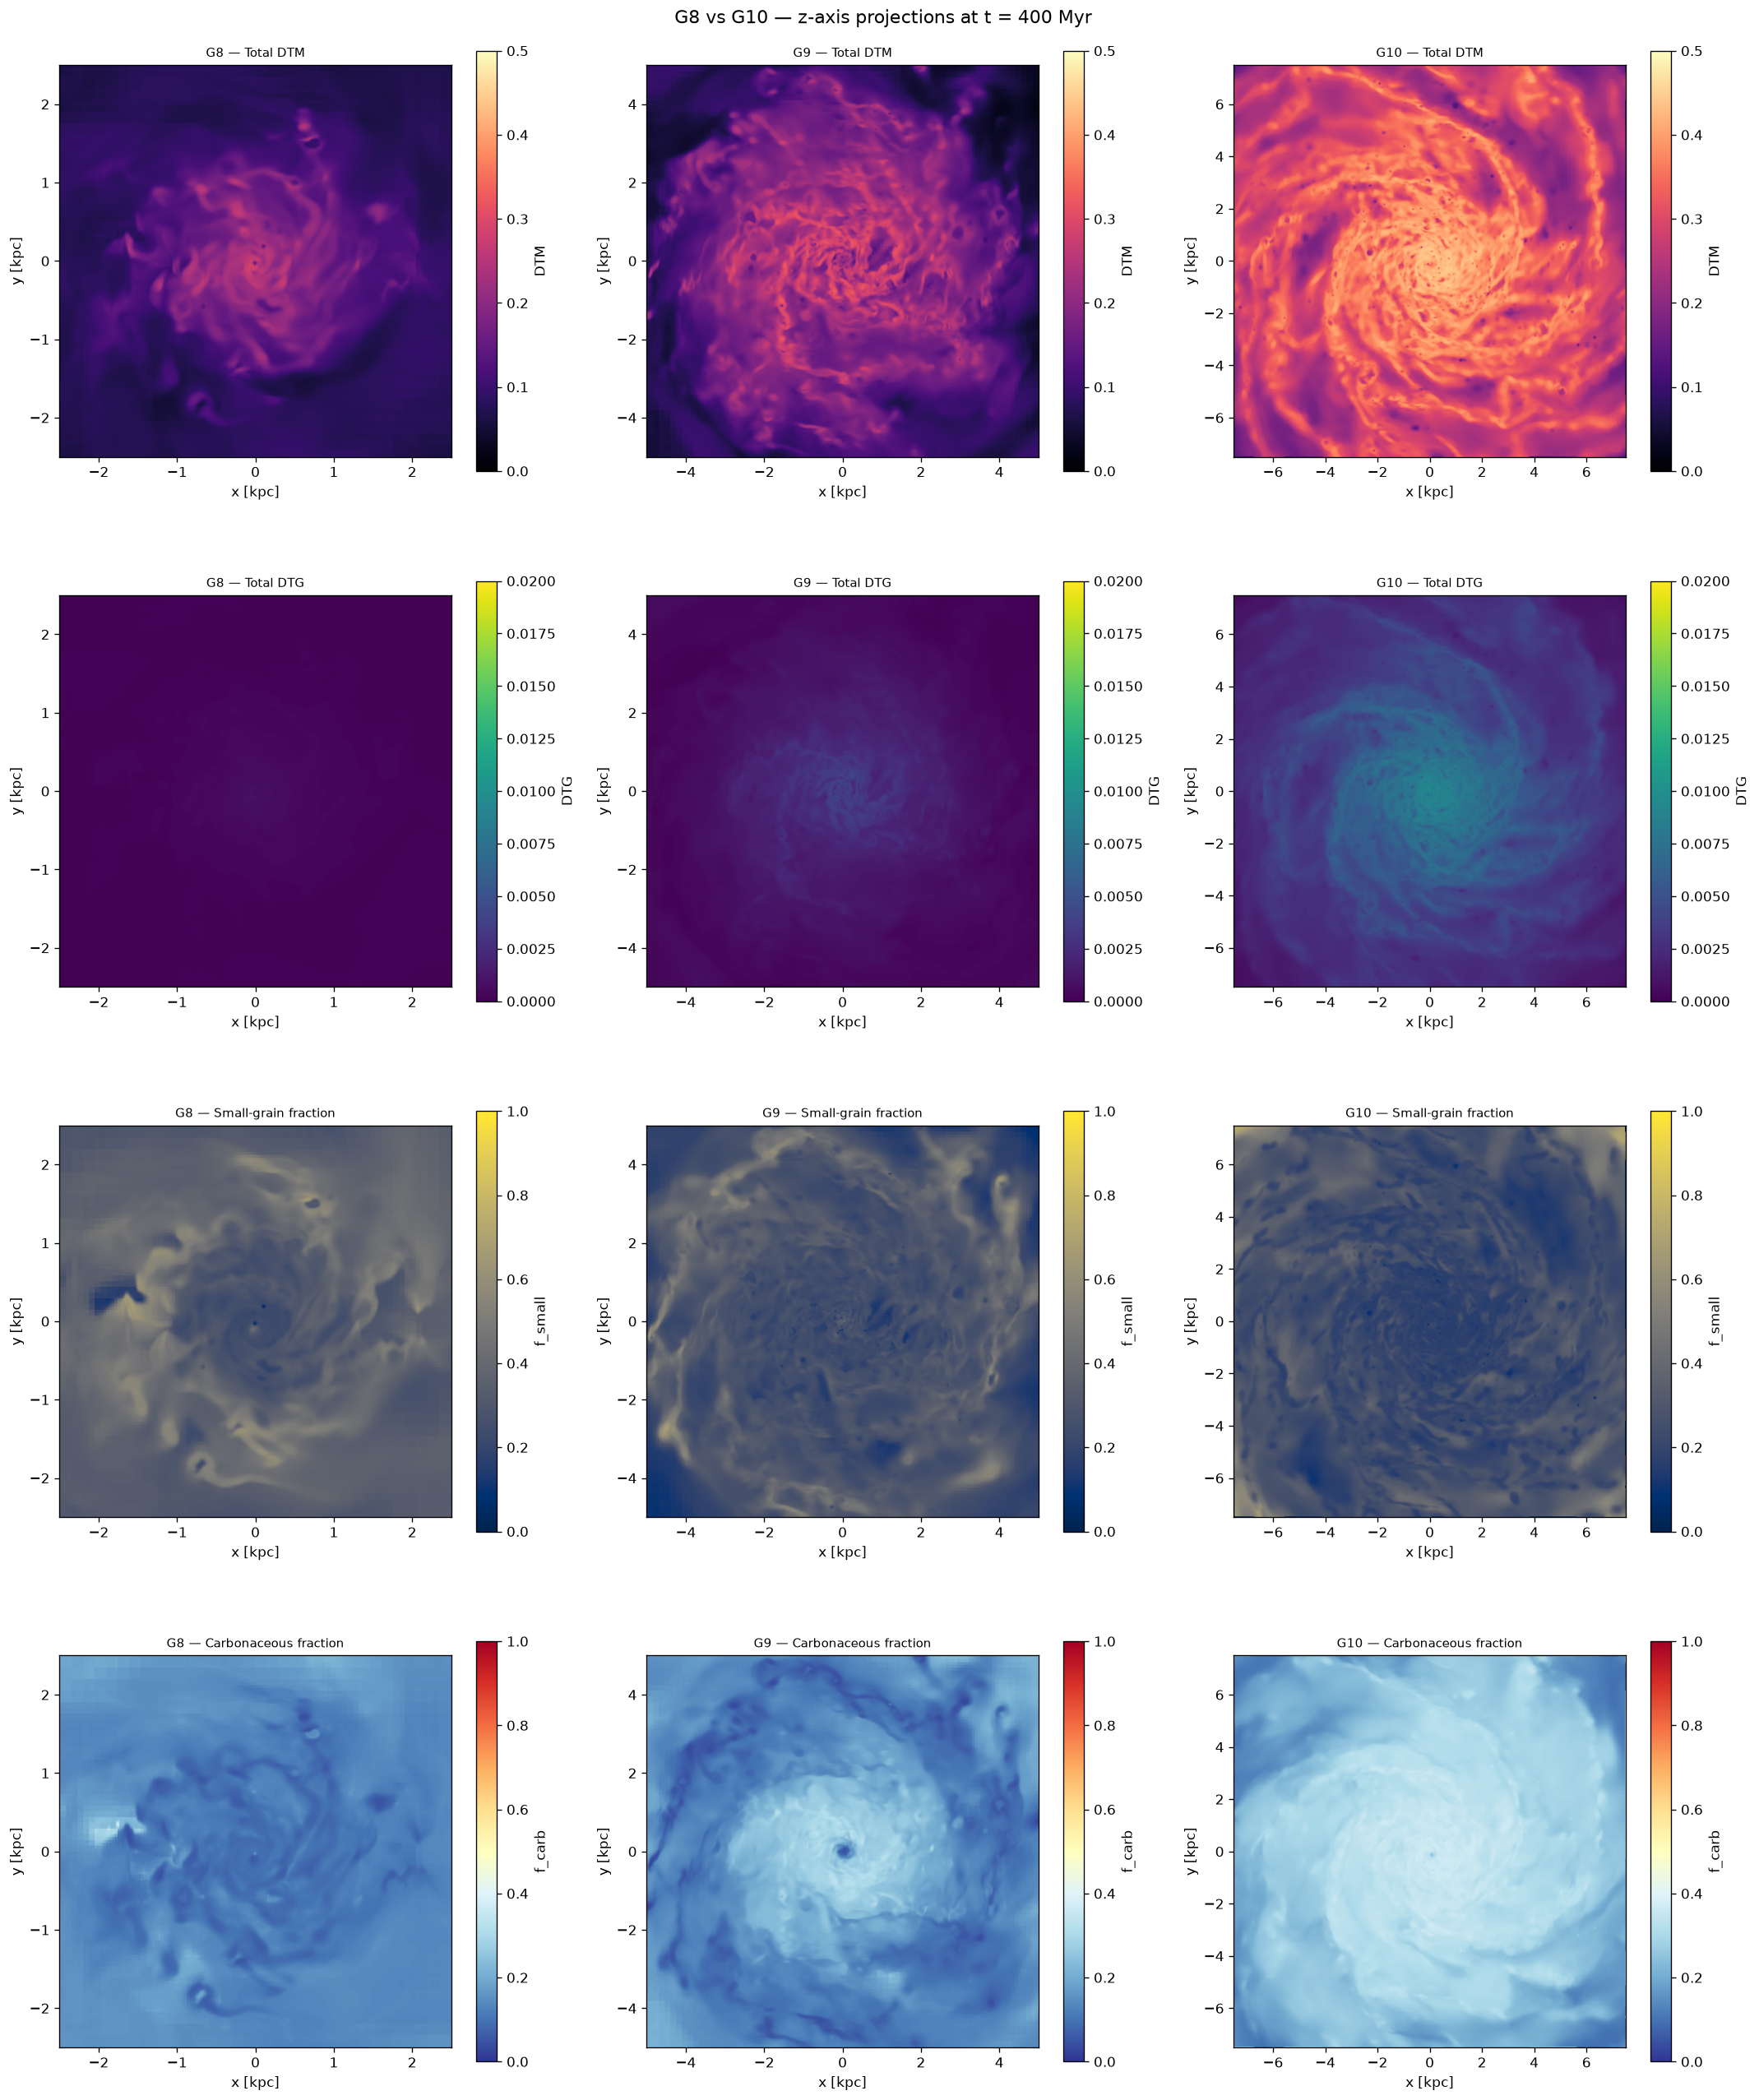

Saved projection_maps.png


In [5]:
# yt field name for each PANELS key
PROJ_FIELDS = {
    'DTM':        ('gas', 'proj_DTM'),
    'DTG':        ('gas', 'proj_DTG'),
    'small_frac': ('gas', 'proj_f_small'),
    'carb_frac':  ('gas', 'proj_f_carb'),
}

def proj_map_yt(ax, sim, field_key, label, cmap, vmin, vmax, resolution=512):
    """Mass-weighted z-projection using yt ds.proj — AMR-correct."""
    ds       = sim['ds']
    region   = sim['region']
    center   = sim['center']
    width    = (sim['width_kpc'], 'kpc')
    yt_field = PROJ_FIELDS[field_key]
    prj = ds.proj(yt_field, 'z', weight_field=('gas', 'density'), data_source=region)
    frb = prj.to_frb(width, resolution, center=center)
    img = np.array(frb[yt_field])
    half = sim['width_kpc'] / 2.0
    im = ax.imshow(img.T, origin='lower',
                   extent=[-half, half, -half, half],
                   cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=9)
    return im

fig, axes = plt.subplots(4, len(SIMS), figsize=(6*len(SIMS), 22))

for row, ((key, ttl, cmap, vmin, vmax, _do_log), clbl) in enumerate(zip(PANELS, CLABELS)):
    for col, sim in enumerate(SIMS):
        ax = axes[row, col]
        im = proj_map_yt(ax, sim, key, f"{sim['tag']} — {ttl}", cmap, vmin, vmax)
        plt.colorbar(im, ax=ax, label=clbl, shrink=0.85)

fig.suptitle('G8 vs G10 — z-axis projections at t = 400 Myr', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'projection_maps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved projection_maps.png')


## 4. Initial Conditions for pyCALIMA Grids

Three ICs used for both simulations:
- **IC_sim**: mass-weighted per-bin DTM from the RAMSES simulation at t = 400 Myr
- **IC_dtmini**: RAMSES t=0 IC — DTM_total = 1e-3, split by Zubko fractions
- **IC_rr14**: Remy-Ruyer 2014 DTM at the simulation metallicity, split by Zubko fractions

In [6]:
def rr2014_dtm(Z_Zsun, dtm_mw=0.40, z_break=0.20, slope_lo=3.0):
    """Remy-Ruyer 2014 DTM relation."""
    dtg_mw  = dtm_mw * ZSUN
    dtg_brk = dtg_mw * z_break
    dtg = (dtg_mw*Z_Zsun if Z_Zsun >= z_break
           else dtg_brk*(Z_Zsun/z_break)**slope_lo)
    return dtg/(Z_Zsun*ZSUN) if Z_Zsun > 0 else 0.0

def make_ics(sim):
    """Build IC dict for a simulation given its Z_ZSUN."""
    Z        = sim['Z_ZSUN']
    dtm_mw   = np.average(sim['DTM_bins'], axis=0, weights=sim['masses'])
    DTM_INI  = 1e-3
    DTM_RR14 = rr2014_dtm(Z)
    return {
        'IC_rr14':   list(ZUBKO_FRACS * DTM_RR14),
    }, DTM_INI, DTM_RR14

for sim in SIMS:
    ics, dtm_ini, dtm_rr14 = make_ics(sim)
    sim['ICS']      = ics
    sim['DTM_INI']  = dtm_ini
    sim['DTM_RR14'] = dtm_rr14
    print(f"\n{sim['tag']}  Z={sim['Z_ZSUN']:.3f} Zsun  DTM_RR14={dtm_rr14:.4f}")
    print(f"  {'IC':<12} {'SmC':>8} {'LgC':>8} {'SmSi':>8} {'LgSi':>8} {'Total':>8}")
    for lbl, dtm in ics.items():
        print(f"  {lbl:<12} {dtm[0]:8.4f} {dtm[1]:8.4f} {dtm[2]:8.4f} {dtm[3]:8.4f} {sum(dtm):8.4f}")
# ── Shared 4-D grid axes (Z and sigma spanning all 3 sims) ───────────────────
Z_all    = np.concatenate([s['Z_Zsun'] * ZSUN for s in SIMS])
sig_all  = np.concatenate([s['sig'] for s in SIMS])
Z_valid  = Z_all[Z_all > 0]
sig_valid= sig_all[sig_all > 0.1]

Z_GRID   = np.logspace(np.log10(np.percentile(Z_valid,   2)),
                        np.log10(np.percentile(Z_valid,  98)), 5)
SIG_GRID = np.logspace(np.log10(np.percentile(sig_valid,  2)),
                        np.log10(np.percentile(sig_valid, 98)), 5)
print(f"\nZ_GRID   [Zsun]: {Z_GRID/ZSUN}")
print(f"SIG_GRID [km/s]: {SIG_GRID}")
print(f"4D grid size: {len(T_GRID)}T × {len(NH_GRID)}nH × {len(Z_GRID)}Z × {len(SIG_GRID)}sig"
      f" = {len(T_GRID)*len(NH_GRID)*len(Z_GRID)*len(SIG_GRID):,} points")



G8  Z=0.136 Zsun  DTM_RR14=0.1847
  IC                SmC      LgC     SmSi     LgSi    Total
  IC_rr14        0.0133   0.0468   0.0194   0.1052   0.1847

G9  Z=0.479 Zsun  DTM_RR14=0.4000
  IC                SmC      LgC     SmSi     LgSi    Total
  IC_rr14        0.0288   0.1015   0.0420   0.2278   0.4000

G10  Z=1.030 Zsun  DTM_RR14=0.4000
  IC                SmC      LgC     SmSi     LgSi    Total
  IC_rr14        0.0288   0.1015   0.0420   0.2278   0.4000



Z_GRID   [Zsun]: [0.08835829 0.19006992 0.40886454 0.87951958 1.89195836]
SIG_GRID [km/s]: [ 0.97159941  2.47930416  6.32662908 16.14414085 41.19623269]
4D grid size: 20T × 20nH × 5Z × 5sig = 10,000 points


## 5. Run pyCALIMA Equilibrium Grids

Run a **4D grid** (T × nH × Z × σ) for each IC combination using the Newton-Krylov (NK) steady-state solver.
The T and nH axes span 20 log-spaced points each; Z and σ use 5 log-spaced points drawn from the
2nd–98th percentile of all three simulations combined.

- **IC_sim**: per-simulation grid seeded from the RAMSES current dust state.
- **IC_dtmini**: shared grid seeded at DTM = 10⁻³ × Zubko fractions.
- **IC_rr14**: shared grid seeded at Rémy-Ruyer+2014(Z) × Zubko fractions.

2D grids at the per-simulation mean (Z, σ) are also computed for the t_end sweep and RK4-vs-NK diagnostic.
Results are cached to `results/comparison/` as `.npz` files — rerun is skipped if the cache exists.


In [ ]:
# ── Config builder — scales elemental abundances to target Z ──────────────────
def make_config_4d(Z_abs, sig_kms, ic_dtm_fracs, solver_cfg, nH=None):
    cfg      = json.load(open(CONFIG_G10))
    cfg['solver'] = copy.deepcopy(solver_cfg)
    Z_Zsun   = Z_abs / ZSUN
    metal_fs = {el: Z_Zsun * f for el, f in SOLAR_METALS.items()}
    tot_met  = sum(metal_fs.values())
    rem      = 1.0 - tot_met
    cfg['elemental_abundances']['H']['mass_fraction']  = rem * _H0 / (_H0 + _He0)
    cfg['elemental_abundances']['He']['mass_fraction'] = rem * _He0 / (_H0 + _He0)
    for el, f in metal_fs.items():
        cfg['elemental_abundances'][el]['mass_fraction'] = f
    cfg['turbulence']['local_sigma_km_s'] = float(max(sig_kms, 1.0))
    # Use caller-supplied nH for the IC density; fall back to config default.
    # This ensures IC DTM = ic_dtm_fracs × Z_abs regardless of cell density.
    nH_ic   = nH if nH is not None else cfg['environment']['hydrogen_number_density_cm3']
    rho_ic  = nH_ic * MH * MU
    for k, db in enumerate(cfg['dust_bins']):
        db['initial_mass_density_gcm3'] = float(ic_dtm_fracs[k] * Z_abs * rho_ic)
    return cfg

def dtm_from_rho_4d(rho_dust_4d):
    DTM_4d = np.zeros_like(rho_dust_4d)
    for iz, Z_abs in enumerate(Z_GRID):
        for j, nH in enumerate(NH_GRID):
            rho_metal = max(Z_abs * nH * MH * MU, 1e-300)
            DTM_4d[:, j, iz, :, :] = rho_dust_4d[:, j, iz, :, :] / rho_metal
    return DTM_4d

def run_or_load_4d(ic_label, sim=None):
    """4D (T, nH, Z, sigma) grid — always NK (Newton-Krylov equilibrium).
    - shared grid: sim=None  → IC_rr14
    """
    prefix = sim['tag'] if sim is not None else 'shared'
    tag    = f"4D_{prefix}_{ic_label}_nk"
    cache  = os.path.join(OUTDIR, f'grid_{tag}.npz')
    if os.path.exists(cache):
        print(f'  [4D {tag}] loaded from cache')
        data = np.load(cache)
        return {k: data[k] for k in data.files}
    nT, nnH, nZ, nS = len(T_GRID), len(NH_GRID), len(Z_GRID), len(SIG_GRID)
    rho_dust_4d = np.zeros((nT, nnH, nZ, nS, 4))
    print(f'  [4D {tag}] running {nZ}x{nS} NK combos ...')
    t0 = time.time()
    for iz, Z_abs in enumerate(Z_GRID):
        Z_Zsun = Z_abs / ZSUN
        for isig, sig in enumerate(SIG_GRID):
            if ic_label == 'IC_rr14':
                ic_fracs = list(ZUBKO_FRACS * rr2014_dtm(Z_Zsun))
            cfg = make_config_4d(Z_abs, sig, ic_fracs, NK_SOLVER)
            tmp = os.path.join(OUTDIR, f'_tmp_4D_{iz}_{isig}.json')
            json.dump(cfg, open(tmp, 'w'))
            g   = run_grid(tmp, x_param='T', x_values=T_GRID,
                           y_param='nH', y_values=NH_GRID,
                           solver_type='newton_krylov', t_end_Myr=399.6,
                           n_jobs=8, verbose=False)
            rho_dust_4d[:, :, iz, isig, :] = g['rho_dust']
            os.remove(tmp)
    print(f'    done in {(time.time()-t0)/60:.1f} min')
    DTM_4d = dtm_from_rho_4d(rho_dust_4d)
    np.savez_compressed(cache, DTM_4d=DTM_4d, rho_dust_4d=rho_dust_4d,
                        T_grid=T_GRID, nH_grid=NH_GRID, Z_grid=Z_GRID, SIG_grid=SIG_GRID)
    return {'DTM_4d': DTM_4d, 'rho_dust_4d': rho_dust_4d,
            'T_grid': T_GRID, 'nH_grid': NH_GRID, 'Z_grid': Z_GRID, 'SIG_grid': SIG_GRID}

# ── Per-sim 2D NK grid at mean Z/sigma — used for Z/sigma sensitivity diagnostic
def make_ic_config_2d_nk(sim, ic_dtm, sigma_kms=None):
    """Build a 2D NK config at the sim's mean Z and (optionally) mean sigma."""
    cfg     = json.load(open(sim['config']))
    cfg['solver'] = copy.deepcopy(NK_SOLVER)
    Z_abs   = sim['Z_ZSUN'] * ZSUN
    nH_ref  = cfg['environment']['hydrogen_number_density_cm3']
    rho_ref = nH_ref * MH * MU
    ok_sig  = sim['sig'] > 0.01
    if sigma_kms is None:
        sigma_kms = (np.average(sim['sig'][ok_sig], weights=sim['masses'][ok_sig])
                     if ok_sig.any() else 5.0)
    cfg['turbulence']['local_sigma_km_s'] = float(max(sigma_kms, 1.0))
    for k, db in enumerate(cfg['dust_bins']):
        db['initial_mass_density_gcm3'] = float(ic_dtm[k] * Z_abs * rho_ref)
    return cfg

def dtm_from_grid_2d(g, Z_gas):
    rho_dust = g['rho_dust']
    DTM = rho_dust.copy()
    for j, nH in enumerate(NH_GRID):
        rho_metal = max(Z_gas * nH * MH * MU, 1e-300)
        DTM[:,j,:] = rho_dust[:,j,:] / rho_metal
    return DTM

def run_or_load_2d_nk(sim):
    """2D NK equilibrium grid at sim's mean Z/sigma — for Z/sigma sensitivity diagnostic."""
    tag   = f"2D_{sim['tag']}_IC_rr14_nk_meanZsig"
    cache = os.path.join(OUTDIR, f'grid_{tag}.npz')
    if os.path.exists(cache):
        data = np.load(cache)
        return {k: data[k] for k in data.files}
    cfg = make_ic_config_2d_nk(sim, sim['ICS']['IC_rr14'])
    tmp = os.path.join(OUTDIR, f'_tmp_{tag}.json')
    json.dump(cfg, open(tmp, 'w'))
    t0 = time.time()
    g  = run_grid(tmp, x_param='T', x_values=T_GRID,
                  y_param='nH', y_values=NH_GRID,
                  solver_type='newton_krylov', t_end_Myr=399.6,
                  n_jobs=8, verbose=False)
    print(f'  [2D NK {sim["tag"]}] done in {(time.time()-t0)/60:.1f} min')
    DTM_grid = dtm_from_grid_2d(g, sim['Z_ZSUN'] * ZSUN)
    np.savez_compressed(cache, DTM_grid=DTM_grid, T_grid=T_GRID, nH_grid=NH_GRID,
                        rho_dust=g['rho_dust'])
    os.remove(tmp)
    return {'DTM_grid': DTM_grid, 'T_grid': T_GRID, 'nH_grid': NH_GRID}

# ── Run / load all grids ──────────────────────────────────────────────────────
IC_LABELS  = ['IC_rr14']

# 4D NK grids — shared IC_rr14 (seeded from RR14(Z) × Zubko fracs)
print('=== 4D NK grids ===')
for sim in SIMS:
    sim['GRID_4D'] = {}

print('  shared IC_rr14 ...')
GRID_4D_RR14   = run_or_load_4d('IC_rr14')
for sim in SIMS:
    sim['GRID_4D']['IC_rr14']   = GRID_4D_RR14

# 2D NK at mean Z/sigma — for Z/sigma sensitivity diagnostic (cell 19/21)
print('\n=== 2D NK grids at mean Z/sigma (IC_rr14) ===')
for sim in SIMS:
    sim['GRID_2D_NK'] = run_or_load_2d_nk(sim)
    print(f'  {sim["tag"]} done.')

print('\nAll grids ready.')


## 5b. Per-cell Solver Comparison — which method matches the simulation better?

For each simulation we sample one representative cell per log-spaced T–nH bin
(10 × 10 bins, ~100 cells total), spanning the full phase diagram.

For each cell we run **two solvers** from the same Rémy-Ruyer+14 IC at that cell's exact (T, nH, Z, σ):
1. **NK equilibrium** (Newton–Krylov, t → ∞)
2. **Anninos 100 Myr** (quasi-implicit dynamical solver, t_end = 100 Myr)

Comparing each result against the RAMSES cell DTM reveals *which method gives better
agreement in each phase of the ISM*, guiding a hybrid strategy for RAMSES-CALIMA.


In [ ]:
from joblib import Parallel, delayed
import tempfile
from solvers.dust_init import load_initial_conditions
from solvers.rhs import build_process_list
from solvers.anninos import _compute_rhs_split

ANNINOS_CFG = {'type': 'anninos', 'errmax': 0.1, 'countmax': 500000,
               'h_max_Myr': 20.0, 'h_init_s': 1.0e8}
NK_CFG      = {'type': 'newton_krylov'}
T_END_DYN   = 100.0   # Myr

N_T_BINS  = 10
N_NH_BINS = 10

def sample_phase_cells(sim, n_t=N_T_BINS, n_nh=N_NH_BINS):
    """Pick the most massive cell in each log-spaced T-nH bin."""
    T_edges  = np.logspace(1.0, 7.0, n_t+1)
    nH_edges = np.logspace(-3.0, 4.0, n_nh+1)
    cells = []
    for it in range(n_t):
        for inh in range(n_nh):
            m = ((sim['T']  >= T_edges[it])   & (sim['T']  < T_edges[it+1]) &
                 (sim['nH'] >= nH_edges[inh]) & (sim['nH'] < nH_edges[inh+1]) &
                 (sim['masses'] > 0))
            if not m.any():
                continue
            idx = np.where(m)[0][sim['masses'][m].argmax()]
            dtm_sim = float(np.nansum(sim['DTM_bins'][idx]))
            if dtm_sim <= 0:
                continue
            cells.append(dict(
                T=float(sim['T'][idx]), nH=float(sim['nH'][idx]),
                Z_abs=float(sim['Z_Zsun'][idx]) * ZSUN,
                sig=max(float(sim['sig'][idx]), 1.0),
                DTM_sim=dtm_sim,
                f_small_sim=float(sim['small_frac'][idx]),
                f_carb_sim=float(sim['carb_frac'][idx]),
            ))
    return cells


def _compute_kmax(T, nH, Z_abs, sig):
    """One RHS evaluation to get the maximum rate constant [s^-1]."""
    ic_fracs = list(ZUBKO_FRACS * rr2014_dtm(Z_abs / ZSUN))
    cfg = make_config_4d(Z_abs, sig, ic_fracs, NK_CFG, nH=nH)
    cfg['environment']['temperature_K']               = T
    cfg['environment']['hydrogen_number_density_cm3'] = nH
    with tempfile.NamedTemporaryFile(suffix='.json', mode='w', delete=False,
                                     dir=OUTDIR) as f:
        json.dump(cfg, f); tmp = f.name
    try:
        state, y_gas, y_dust = load_initial_conditions(tmp)
    finally:
        os.unlink(tmp)
    processes = build_process_list(state)
    _, _, _, kmax = _compute_rhs_split(state, y_gas, y_dust, processes)
    return float(kmax)


def _run_one_cell(T, nH, Z_abs, sig, solver_cfg, t_end_Myr):
    """Run solver at a single (T, nH, Z, sig) point.

    Returns
    -------
    dtm : float
        Total dust-to-metals ratio.
    f_small : float
        Mass fraction in small grains (bins 0+2: small graphite + small silicate).
    f_carb : float
        Mass fraction in carbonaceous grains (bins 0+1: small+large graphite).
    """
    ic_fracs = list(ZUBKO_FRACS * rr2014_dtm(Z_abs / ZSUN))
    cfg = make_config_4d(Z_abs, sig, ic_fracs, solver_cfg, nH=nH)
    cfg['environment']['temperature_K']               = T
    cfg['environment']['hydrogen_number_density_cm3'] = nH
    with tempfile.NamedTemporaryFile(suffix='.json', mode='w', delete=False,
                                     dir=OUTDIR) as f:
        json.dump(cfg, f); tmp = f.name
    try:
        g = run_grid(tmp, x_param='T', x_values=[T],
                     y_param='nH', y_values=[nH],
                     solver_type=solver_cfg['type'],
                     t_end_Myr=t_end_Myr, n_jobs=1, verbose=False)
    finally:
        os.unlink(tmp)
    # Bin order: [small_graphite, large_graphite, small_silicate, large_silicate]
    rho_d    = g['rho_dust'][0, 0]
    total_d  = float(np.sum(rho_d))
    rho_metal = max(Z_abs * nH * MH * MU, 1e-300)
    dtm = total_d / rho_metal
    if total_d > 0:
        f_small = float((rho_d[0] + rho_d[2]) / total_d)
        f_carb  = float((rho_d[0] + rho_d[1]) / total_d)
    else:
        f_small = 0.0
        f_carb  = 0.0
    return dtm, f_small, f_carb


def _do_cell(cell):
    """Run both solvers + kmax for one cell."""
    T, nH, Z, sig = cell['T'], cell['nH'], cell['Z_abs'], cell['sig']
    kmax                     = _compute_kmax(T, nH, Z, sig)
    dtm_nk,  fs_nk,  fc_nk  = _run_one_cell(T, nH, Z, sig, NK_CFG,      400.0)
    dtm_ann, fs_ann, fc_ann  = _run_one_cell(T, nH, Z, sig, ANNINOS_CFG, T_END_DYN)
    return dtm_nk, dtm_ann, kmax, fs_nk, fc_nk, fs_ann, fc_ann


def run_or_load_per_cell(sim):
    """Run per-cell comparison for one simulation; cache to npz."""
    cache = os.path.join(OUTDIR, f'per_cell_comparison_{sim["tag"]}.npz')
    if os.path.exists(cache):
        d = np.load(cache)
        if 'fs_sim' in d.files:   # current format includes dust fractions
            print(f'  [{sim["tag"]}] loaded from cache')
            return {k: d[k] for k in d.files}
        print(f'  [{sim["tag"]}] old cache (no fractions) — recomputing ...')
        os.remove(cache)
    cells = sample_phase_cells(sim)
    print(f'  [{sim["tag"]}] {len(cells)} cells — NK + Anninos {T_END_DYN:.0f} Myr + kmax ...')
    t0 = time.time()
    results = Parallel(n_jobs=6, prefer='processes')(
        delayed(_do_cell)(c) for c in cells)
    print(f'    done in {(time.time()-t0)/60:.1f} min')
    T_arr    = np.array([c['T']           for c in cells])
    nH_arr   = np.array([c['nH']          for c in cells])
    Z_arr    = np.array([c['Z_abs']        for c in cells])
    sig_arr  = np.array([c['sig']          for c in cells])
    DTM_sim  = np.array([c['DTM_sim']      for c in cells])
    fs_sim   = np.array([c['f_small_sim']  for c in cells])
    fc_sim   = np.array([c['f_carb_sim']   for c in cells])
    DTM_NK   = np.array([r[0] for r in results])
    DTM_ANN  = np.array([r[1] for r in results])
    kmax_arr = np.array([r[2] for r in results])
    fs_NK    = np.array([r[3] for r in results])
    fc_NK    = np.array([r[4] for r in results])
    fs_ANN   = np.array([r[5] for r in results])
    fc_ANN   = np.array([r[6] for r in results])
    np.savez_compressed(cache,
                        T=T_arr, nH=nH_arr, Z_abs=Z_arr, sig=sig_arr,
                        DTM_sim=DTM_sim, DTM_NK=DTM_NK, DTM_ANN=DTM_ANN,
                        kmax=kmax_arr,
                        fs_sim=fs_sim, fc_sim=fc_sim,
                        fs_NK=fs_NK,   fc_NK=fc_NK,
                        fs_ANN=fs_ANN, fc_ANN=fc_ANN)
    return dict(T=T_arr, nH=nH_arr, Z_abs=Z_arr, sig=sig_arr,
                DTM_sim=DTM_sim, DTM_NK=DTM_NK, DTM_ANN=DTM_ANN, kmax=kmax_arr,
                fs_sim=fs_sim, fc_sim=fc_sim,
                fs_NK=fs_NK,   fc_NK=fc_NK,
                fs_ANN=fs_ANN, fc_ANN=fc_ANN)


print('\n=== Per-cell solver comparison ===')
PER_CELL = [run_or_load_per_cell(sim) for sim in SIMS]
print('Done.')


## 5c. Winner Phase Map

Each dot is one sampled cell.  Colour shows `|bias_Anninos| − |bias_NK|` where
`bias = log₁₀(DTM_pred / DTM_sim)`:
- **Blue** → NK equilibrium is closer to the simulation
- **Red** → Anninos 100 Myr is closer

Also shown: the absolute bias of each method separately.


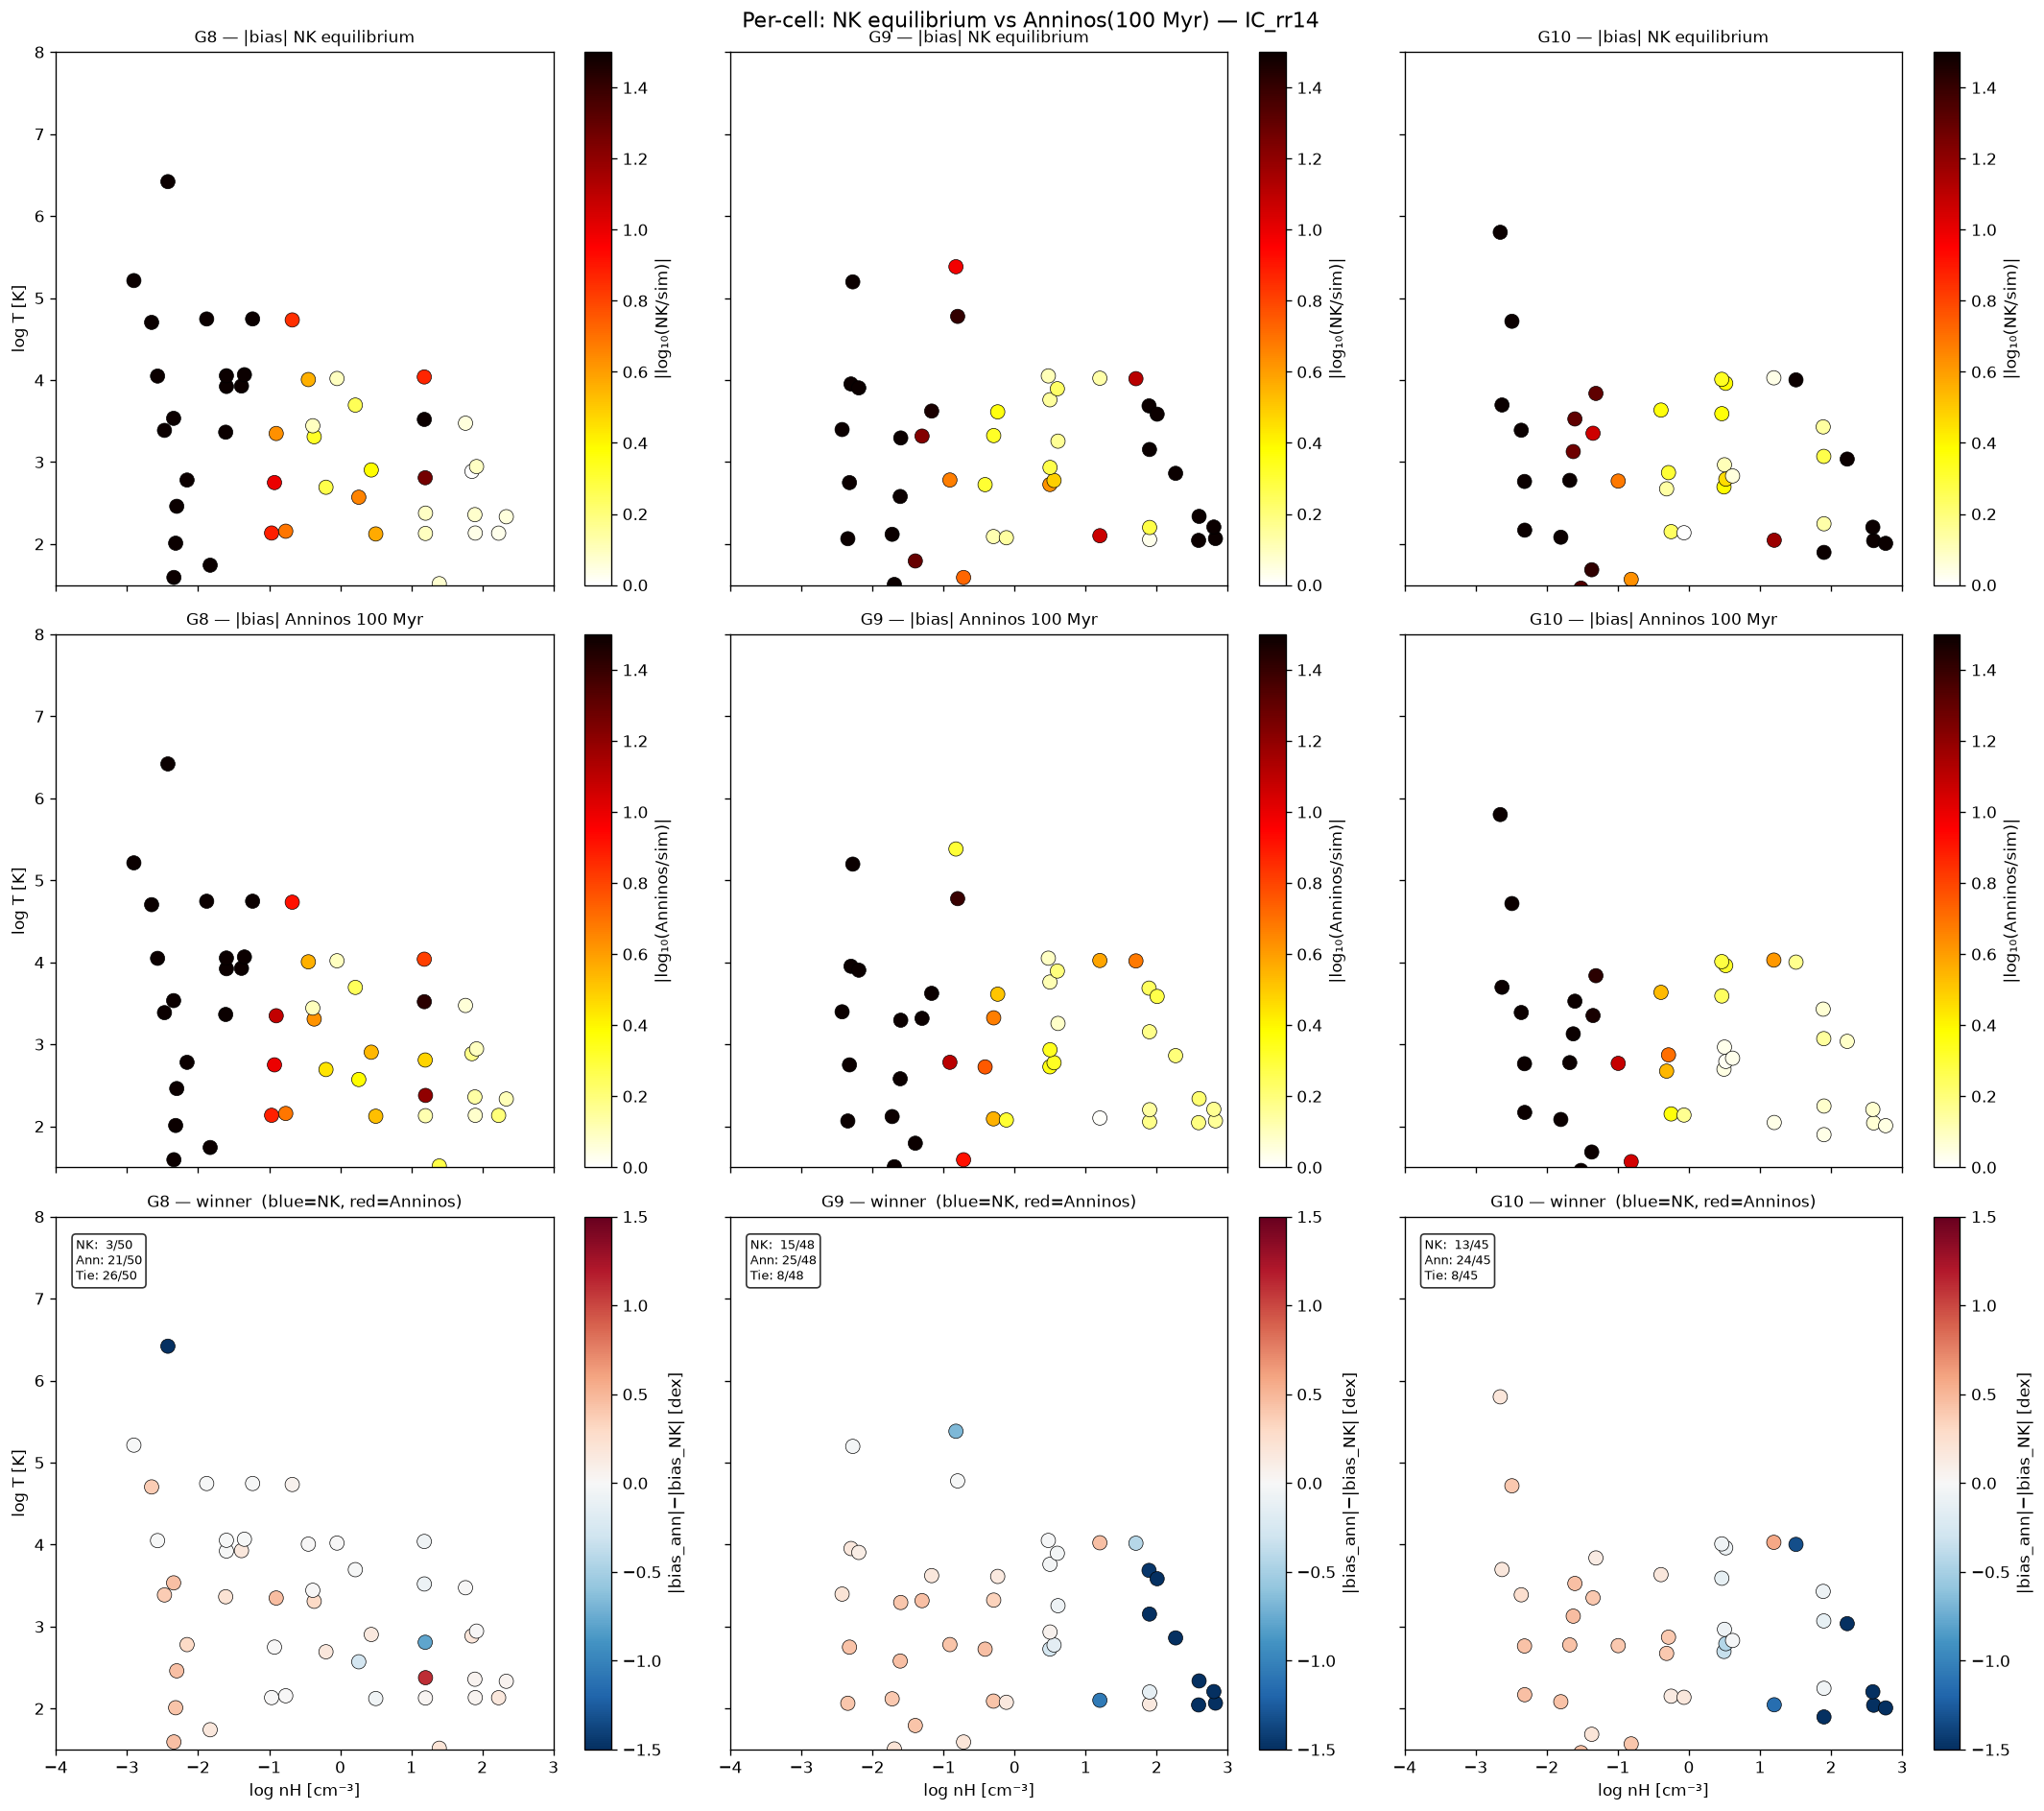

Saved /Users/currodri/Documents/GitHub/pyCALIMA/results/comparison/per_cell_solver_comparison.png

Sim     cells   med|bias_NK|   med|bias_Ann|   NK wins   Ann wins
--------------------------------------------------------------
G8         50          0.861           0.900         3         21
G9         48          1.170           0.436        15         25
G10        45          1.064           0.369        13         24


In [9]:
fig, axes = plt.subplots(3, len(SIMS), figsize=(6*len(SIMS), 16),
                          sharex=True, sharey=True)
fig.suptitle(
    f'Per-cell: NK equilibrium vs Anninos({T_END_DYN:.0f} Myr) — IC_rr14',
    fontsize=13)

scatter_kw = dict(s=80, edgecolors='k', linewidths=0.4)

for col, (sim, pc) in enumerate(zip(SIMS, PER_CELL)):
    T, nH = pc['T'], pc['nH']
    DTM_s, DTM_nk, DTM_ann = pc['DTM_sim'], pc['DTM_NK'], pc['DTM_ANN']

    eps = 1e-5
    ok  = (DTM_s > eps) & (DTM_nk > eps) & (DTM_ann > eps)
    lnH = np.log10(nH[ok])
    lT  = np.log10(T[ok])

    bias_nk  = np.log10(DTM_nk[ok]  / DTM_s[ok])
    bias_ann = np.log10(DTM_ann[ok] / DTM_s[ok])
    winner   = np.abs(bias_ann) - np.abs(bias_nk)   # <0 → NK better

    # Row 0: |bias| NK
    sc0 = axes[0, col].scatter(lnH, lT, c=np.abs(bias_nk),
                                vmin=0, vmax=1.5, cmap='hot_r', **scatter_kw)
    axes[0, col].set_title(f'{sim["tag"]} — |bias| NK equilibrium', fontsize=10)
    plt.colorbar(sc0, ax=axes[0, col], label='|log₁₀(NK/sim)|')

    # Row 1: |bias| Anninos
    sc1 = axes[1, col].scatter(lnH, lT, c=np.abs(bias_ann),
                                vmin=0, vmax=1.5, cmap='hot_r', **scatter_kw)
    axes[1, col].set_title(f'{sim["tag"]} — |bias| Anninos {T_END_DYN:.0f} Myr', fontsize=10)
    plt.colorbar(sc1, ax=axes[1, col], label='|log₁₀(Anninos/sim)|')

    # Row 2: winner map
    lim = 1.5
    sc2 = axes[2, col].scatter(lnH, lT, c=winner,
                                vmin=-lim, vmax=lim, cmap='RdBu_r', **scatter_kw)
    axes[2, col].set_title(f'{sim["tag"]} — winner  (blue=NK, red=Anninos)', fontsize=10)
    plt.colorbar(sc2, ax=axes[2, col], label='|bias_ann|−|bias_NK| [dex]')

    n_nk  = int(np.sum(winner < -0.1))
    n_ann = int(np.sum(winner >  0.1))
    n_tie = int(np.sum(np.abs(winner) <= 0.1))
    axes[2, col].text(0.04, 0.96,
        f'NK:  {n_nk}/{ok.sum()}\nAnn: {n_ann}/{ok.sum()}\nTie: {n_tie}/{ok.sum()}',
        transform=axes[2, col].transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

for row_axes in axes:
    row_axes[0].set_ylabel('log T [K]')
for col in range(len(SIMS)):
    axes[-1, col].set_xlabel('log nH [cm⁻³]')
    for ax in axes[:, col]:
        ax.set_xlim(NH_LO, NH_HI)
        ax.set_ylim(T_LO, T_HI)

fig.tight_layout()
out_path = os.path.join(OUTDIR, 'per_cell_solver_comparison.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out_path}')

# ── Scalar summary ────────────────────────────────────────────────────────────
print(f"\n{'Sim':<6}  {'cells':>5}  {'med|bias_NK|':>13}  {'med|bias_Ann|':>14}  {'NK wins':>8}  {'Ann wins':>9}")
print('-' * 62)
for sim, pc in zip(SIMS, PER_CELL):
    DTM_s, DTM_nk, DTM_ann = pc['DTM_sim'], pc['DTM_NK'], pc['DTM_ANN']
    eps = 1e-5
    ok  = (DTM_s > eps) & (DTM_nk > eps) & (DTM_ann > eps)
    b_nk  = np.abs(np.log10(DTM_nk[ok]  / DTM_s[ok]))
    b_ann = np.abs(np.log10(DTM_ann[ok] / DTM_s[ok]))
    winner = b_ann - b_nk
    n_nk  = int(np.sum(winner < -0.1))
    n_ann = int(np.sum(winner >  0.1))
    print(f"{sim['tag']:<6}  {ok.sum():>5}  {np.median(b_nk):>13.3f}  {np.median(b_ann):>14.3f}  {n_nk:>8}  {n_ann:>9}")


## 5d. Hybrid Approach — Quantitative Comparison

For each of the ~100 sampled cells we already have **DTM_NK** and **DTM_ANN**.
We test four switching criteria that choose one of the two for each cell and
measure the resulting bias against the RAMSES ground truth.

| Approach | Criterion | Switch point |
|---|---|---|
| **A1** — density threshold | nH > n_thresh | n_thresh ∈ {0.3, 1, 3, 10} cm⁻³ |
| **A2** — accretion timescale | τ_acc = C/(Z nH) > T_eval | C ∈ {100, 300, 1000} Myr |
| **A3** — rate criterion | kmax × T_eval < ε (not yet eq.) | ε ∈ {1, 3, 10} |
| **A4** — convergence gap | \|DTM_NK − DTM_ANN\|/DTM_NK > tol | tol ∈ {0.1, 0.3, 1.0} |

Baselines: **always NK**, **always Anninos**, **oracle** (best of the two per cell).
Metrics: median |bias|, fraction within 0.3 dex, fraction within 1 dex.


In [19]:
T_EVAL_S = T_END_DYN * 3.15e13   # 100 Myr in seconds

def apply_hybrid(pc, approach, **kw):
    """Return (DTM_hyb, use_ann) for the given approach.

    ``use_ann`` is a boolean mask; True = use Anninos, False = use NK.
    The same mask is then applied to fs/fc fractions by the caller.
    """
    T, nH = pc['T'], pc['nH']
    DTM_s, DTM_nk, DTM_ann = pc['DTM_sim'], pc['DTM_NK'], pc['DTM_ANN']
    Z_abs = pc.get('Z_abs', np.ones_like(T) * ZSUN)
    kmax  = pc.get('kmax',  np.ones_like(T) * 1e-30)

    if approach == 'oracle_DTM':
        b_nk  = np.abs(np.log10(np.maximum(DTM_nk,  1e-10) / np.maximum(DTM_s, 1e-10)))
        b_ann = np.abs(np.log10(np.maximum(DTM_ann, 1e-10) / np.maximum(DTM_s, 1e-10)))
        use_ann = b_ann < b_nk

    elif approach == 'oracle_fs':
        fs_s, fs_nk, fs_ann = pc['fs_sim'], pc['fs_NK'], pc['fs_ANN']
        b_nk  = np.abs(np.log10(np.maximum(fs_nk,  1e-6) / np.maximum(fs_s, 1e-6)))
        b_ann = np.abs(np.log10(np.maximum(fs_ann, 1e-6) / np.maximum(fs_s, 1e-6)))
        use_ann = b_ann < b_nk

    elif approach == 'oracle_fc':
        fc_s, fc_nk, fc_ann = pc['fc_sim'], pc['fc_NK'], pc['fc_ANN']
        b_nk  = np.abs(np.log10(np.maximum(fc_nk,  1e-6) / np.maximum(fc_s, 1e-6)))
        b_ann = np.abs(np.log10(np.maximum(fc_ann, 1e-6) / np.maximum(fc_s, 1e-6)))
        use_ann = b_ann < b_nk

    elif approach == 'A1':
        use_ann = nH > kw.get('n_thresh', 1.0)

    elif approach == 'A2':
        C_acc  = kw.get('C_acc', 300.0)
        Z_Zsun = np.maximum(Z_abs / ZSUN, 1e-10)
        tau    = C_acc / (Z_Zsun * nH)
        use_ann = tau > T_END_DYN

    elif approach == 'A3':
        eps = kw.get('epsilon', 3.0)
        use_ann = kmax * T_EVAL_S < eps

    elif approach == 'A4':
        tol     = kw.get('tol', 0.3)
        gap     = np.abs(DTM_nk - DTM_ann) / np.maximum(DTM_nk, 1e-10)
        use_ann = gap > tol

    else:
        raise ValueError(approach)

    DTM_hyb = np.where(use_ann, DTM_ann, DTM_nk)
    return DTM_hyb, use_ann


def apply_fracs(pc, use_ann):
    """Apply use_ann mask to select f_small and f_carb per cell."""
    fs_hyb = np.where(use_ann, pc['fs_ANN'], pc['fs_NK'])
    fc_hyb = np.where(use_ann, pc['fc_ANN'], pc['fc_NK'])
    return fs_hyb, fc_hyb


def metrics_q(hyb, sim, valid, label=''):
    """Log10-bias metrics on the common valid set."""
    eps = 1e-6
    ok  = valid & (sim > eps) & (hyb > eps)
    if not ok.any():
        return dict(label=label, n=0, med=np.nan, f03=0., f10=0.)
    bias = np.log10(hyb[ok] / sim[ok])
    ab   = np.abs(bias)
    return dict(label=label, n=int(ok.sum()),
                med=float(np.median(ab)),
                f03=float((ab < 0.3).mean()),
                f10=float((ab < 1.0).mean()))


# ── Pooled data ───────────────────────────────────────────────────────────────
ALL_PC = {k: np.concatenate([pc[k] for pc in PER_CELL])
          for k in PER_CELL[0].keys()}

eps = 1e-5
common = ((ALL_PC['DTM_sim'] > eps) &
          (ALL_PC['DTM_NK']  > eps) &
          (ALL_PC['DTM_ANN'] > eps))
print(f'Common valid set: {common.sum()} / {len(common)} cells')

METHODS = [
    ('Always NK',      lambda pc: (pc['DTM_NK'],  np.zeros(len(pc['T']), bool))),
    ('Always Anninos', lambda pc: (pc['DTM_ANN'], np.ones( len(pc['T']), bool))),
    ('Oracle (DTM)',   lambda pc: apply_hybrid(pc, 'oracle_DTM')),
    ('Oracle (fs)',    lambda pc: apply_hybrid(pc, 'oracle_fs')),
    ('Oracle (fc)',    lambda pc: apply_hybrid(pc, 'oracle_fc')),
    ('A1  nH>0.3',    lambda pc: apply_hybrid(pc, 'A1', n_thresh=0.3)),
    ('A1  nH>1',      lambda pc: apply_hybrid(pc, 'A1', n_thresh=1.0)),
    ('A1  nH>3',      lambda pc: apply_hybrid(pc, 'A1', n_thresh=3.0)),
    ('A1  nH>10',     lambda pc: apply_hybrid(pc, 'A1', n_thresh=10.0)),
    ('A2  C=100 Myr', lambda pc: apply_hybrid(pc, 'A2', C_acc=100.0)),
    ('A2  C=300 Myr', lambda pc: apply_hybrid(pc, 'A2', C_acc=300.0)),
    ('A2  C=1000 Myr',lambda pc: apply_hybrid(pc, 'A2', C_acc=1000.0)),
    ('A3  e=1',       lambda pc: apply_hybrid(pc, 'A3', epsilon=1.0)),
    ('A3  e=3',       lambda pc: apply_hybrid(pc, 'A3', epsilon=3.0)),
    ('A3  e=10',      lambda pc: apply_hybrid(pc, 'A3', epsilon=10.0)),
    ('A4  tol=0.1',   lambda pc: apply_hybrid(pc, 'A4', tol=0.1)),
    ('A4  tol=0.3',   lambda pc: apply_hybrid(pc, 'A4', tol=0.3)),
    ('A4  tol=1.0',   lambda pc: apply_hybrid(pc, 'A4', tol=1.0)),
]

rows = []
for name, fn in METHODS:
    DTM_hyb, use_ann = fn(ALL_PC)
    fs_hyb, fc_hyb   = apply_fracs(ALL_PC, use_ann)
    rows.append(dict(
        label=name,
        dtm =metrics_q(DTM_hyb, ALL_PC['DTM_sim'], common),
        fs  =metrics_q(fs_hyb,  ALL_PC['fs_sim'],  common),
        fc  =metrics_q(fc_hyb,  ALL_PC['fc_sim'],  common),
    ))

# ── Print three-quantity table ─────────────────────────────────────────────────
def _fmt(r):
    if r['n'] == 0: return f"{'—':>6}  {'—':>7}  {'—':>6}"
    return f"{r['med']:>6.3f}  {r['f03']:>7.1%}  {r['f10']:>6.1%}"

hdr  = f"{'Method':<22}  {'──── DTM ────':^22}  {'── f_small ──':^22}  {'── f_carb ──':^22}"
hdr2 = f"{'':22}  {'med|b|':>6}  {'f<.3dx':>7}  {'f<1dx':>6}  " * 3
print(hdr)
print(hdr2)
print('─' * 98)
BASELINES = {'Always NK', 'Always Anninos', 'Oracle (DTM)', 'Oracle (fs)', 'Oracle (fc)'}
for r in rows:
    mark = ' ◀' if r['label'] in BASELINES else ''
    print(f"{r['label']:<22}  {_fmt(r['dtm'])}  {_fmt(r['fs'])}  {_fmt(r['fc'])}{mark}")


Common valid set: 153 / 202 cells

Method                     ──── DTM ────        ── f_small ──        ── f_carb ──
                          med   f<.3    f<1    med   f<.3    f<1    med   f<.3    f<1
──────────────────────────────────────────────────────────────────────────────────────────
NK equilibrium          0.651  13.1%  75.8%  0.179  68.5%  95.1%  0.257  61.5%  97.0%
Anninos  100 Myr        0.682   2.6%  73.2%  0.135  84.2%  98.7%  0.281  58.8%  98.0%
Anninos  tff/snap       0.676   3.3%  69.3%  0.103  88.8%  99.3%  0.264  56.2% 100.0%

DTM by density bin (median values):
  bin              n   DTM_sim  IC_rr14  ANN_100   ANN_tff     NK
  ─────────────────────────────────────────────────────────────────
  diffuse <0.1     81   0.0364   0.2314    0.1532    0.1404   0.0030
  warm 0.1-1       42   0.0474   0.2750    0.0623    0.0577   0.1119
  ISM 1-30         48   0.0540   0.3244    0.1344    0.1266   0.1780
  dense >30        31   0.1130   0.3350    0.4658    0.3690   0.2246


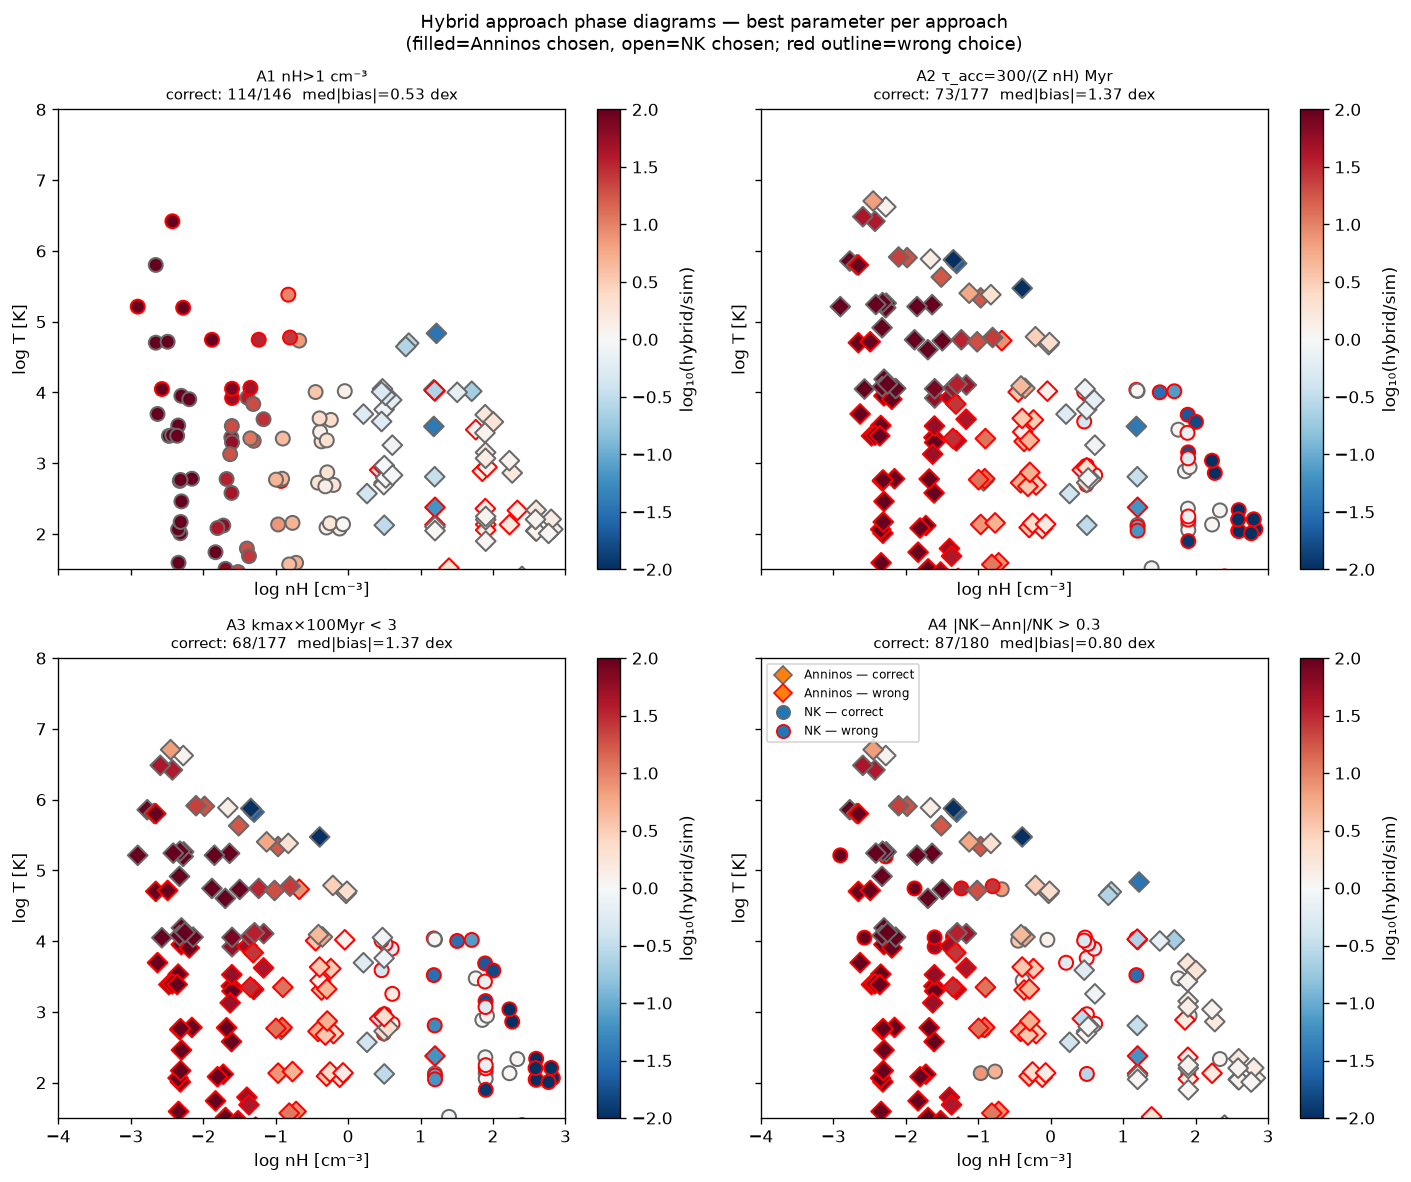

Saved hybrid_approach_comparison.png


In [11]:
# Best parameter per approach (from the table above)
BEST_METHODS = {
    'A1': dict(n_thresh=1.0),
    'A2': dict(C_acc=300.0),
    'A3': dict(epsilon=3.0),
    'A4': dict(tol=0.3),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()
fig.suptitle('Hybrid approach phase diagrams — best parameter per approach\n'
             '(filled=Anninos chosen, open=NK chosen; red outline=wrong choice)',
             fontsize=11)

approach_labels = {
    'A1': f'A1 nH>1 cm⁻³',
    'A2': f'A2 τ_acc=300/(Z nH) Myr',
    'A3': f'A3 kmax×100Myr < 3',
    'A4': f'A4 |NK−Ann|/NK > 0.3',
}

eps = 1e-5

for ax, (appr, kw) in zip(axes, BEST_METHODS.items()):
    DTM_hyb, use_ann = apply_hybrid(ALL_PC, appr, **kw)
    DTM_oracle, oracle_ann = apply_hybrid(ALL_PC, 'oracle')

    T, nH = ALL_PC['T'], ALL_PC['nH']
    DTM_s = ALL_PC['DTM_sim']
    ok = (DTM_s > eps) & (DTM_hyb > eps)

    lnH = np.log10(nH[ok])
    lT  = np.log10(T[ok])
    bias = np.log10(DTM_hyb[ok] / DTM_s[ok])
    correct = (use_ann[ok] == oracle_ann[ok])   # chose same as oracle?

    # marker: filled=Anninos, open=NK; edge colour: grey=correct, red=wrong
    ann_mask = use_ann[ok]
    ec = np.where(correct, 'dimgray', 'red')
    fc_ann = np.where(correct[ann_mask],  'C1', 'C1')
    fc_nk  = np.where(correct[~ann_mask], 'C0', 'C0')

    sc = ax.scatter(lnH[~ann_mask], lT[~ann_mask],
                    c=bias[~ann_mask], vmin=-2, vmax=2, cmap='RdBu_r',
                    edgecolors=ec[~ann_mask], linewidths=1.2,
                    s=70, marker='o', label='NK chosen')
    ax.scatter(lnH[ann_mask], lT[ann_mask],
               c=bias[ann_mask], vmin=-2, vmax=2, cmap='RdBu_r',
               edgecolors=ec[ann_mask], linewidths=1.2,
               s=70, marker='D', label='Anninos chosen')

    plt.colorbar(sc, ax=ax, label='log₁₀(hybrid/sim)')
    n_correct = correct.sum()
    n_tot = ok.sum()
    med_ab = np.median(np.abs(bias))
    ax.set_title(f'{approach_labels[appr]}\n'
                 f'correct: {n_correct}/{n_tot}  med|bias|={med_ab:.2f} dex',
                 fontsize=9)
    ax.set_xlim(NH_LO, NH_HI); ax.set_ylim(T_LO, T_HI)
    ax.set_xlabel('log nH [cm⁻³]')
    ax.set_ylabel('log T [K]')

# Legend (one entry for correct vs wrong)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='D', color='w', markerfacecolor='C1',
           markeredgecolor='dimgray', markersize=8, label='Anninos — correct'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='C1',
           markeredgecolor='red', markersize=8, label='Anninos — wrong'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='C0',
           markeredgecolor='dimgray', markersize=8, label='NK — correct'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='C0',
           markeredgecolor='red', markersize=8, label='NK — wrong'),
]
axes[-1].legend(handles=legend_elements, loc='upper left', fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'hybrid_approach_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved hybrid_approach_comparison.png')


## 6. Interpolation and Bias Helpers

Interpolate the **4D equilibrium grid** (T, nH, Z, σ) onto every simulation cell's individual
(T, nH, Z, σ) values using `scipy.interpolate.RegularGridInterpolator`, then compute
the mass-weighted bias = log₁₀(sim / model) per dust bin and in total.

Per-cell metallicity Z and velocity dispersion σ come directly from the RAMSES fields,
not from simulation-mean values.


In [12]:
def interp_grid(DTM_grid, T_s, nH_s):
    """2D bilinear — for t_end sweep and RK4-vs-NK."""
    pts = np.column_stack([
        np.log10(np.clip(T_s,  T_GRID[0],  T_GRID[-1])),
        np.log10(np.clip(nH_s, NH_GRID[0], NH_GRID[-1]))])
    out = np.full((len(T_s), 4), np.nan)
    for k in range(4):
        interp = RegularGridInterpolator(
            (np.log10(T_GRID), np.log10(NH_GRID)), DTM_grid[:,:,k],
            method='linear', bounds_error=False, fill_value=np.nan)
        out[:,k] = interp(pts)
    return out

def interp_4d(DTM_4d, T_s, nH_s, Z_s, sig_s):
    """4D bilinear — per-cell T, nH, Z, sigma."""
    pts = np.column_stack([
        np.log10(np.clip(T_s,   T_GRID[0],   T_GRID[-1])),
        np.log10(np.clip(nH_s,  NH_GRID[0],  NH_GRID[-1])),
        np.log10(np.clip(Z_s,   Z_GRID[0],   Z_GRID[-1])),
        np.log10(np.clip(sig_s, SIG_GRID[0], SIG_GRID[-1])),
    ])
    out = np.full((len(T_s), 4), np.nan)
    for k in range(4):
        interp = RegularGridInterpolator(
            (np.log10(T_GRID), np.log10(NH_GRID), np.log10(Z_GRID), np.log10(SIG_GRID)),
            DTM_4d[:,:,:,:,k],
            method='linear', bounds_error=False, fill_value=np.nan)
        out[:,k] = interp(pts)
    return out

def get_DTM_eq(sim, ic_label):
    """All ICs: 4D NK equilibrium with per-cell Z and sigma."""
    Z_s   = sim['Z_Zsun'] * ZSUN
    sig_s = np.clip(sim['sig'], 0.1, None)
    return interp_4d(sim['GRID_4D'][ic_label]['DTM_4d'],
                     sim['T'], sim['nH'], Z_s, sig_s)

def compute_bias(DTM_sim, DTM_eq, masses, T_s, nH_s, T_max=5e4, nH_min=1e-3):
    base   = (T_s < T_max) & (nH_s > nH_min)
    tot_s  = np.nansum(DTM_sim, axis=1)
    tot_eq = np.nansum(DTM_eq,  axis=1)
    res = {}
    for k, name in enumerate(BIN_NAMES):
        ok = base & (DTM_eq[:,k]>0) & (DTM_sim[:,k]>0) & np.isfinite(DTM_eq[:,k])
        if ok.sum() == 0:
            res[name] = (np.nan, np.nan, 0); continue
        d = np.log10(DTM_sim[ok,k]) - np.log10(DTM_eq[ok,k])
        res[name] = (np.average(d, weights=masses[ok]),
                     np.sqrt(np.average(d**2, weights=masses[ok])),
                     ok.sum())
    ok_t = base & (tot_eq>0) & (tot_s>0) & np.isfinite(tot_eq)
    d_t  = np.log10(tot_s[ok_t]) - np.log10(tot_eq[ok_t])
    res['TOTAL'] = (np.average(d_t, weights=masses[ok_t]),
                    np.sqrt(np.average(d_t**2, weights=masses[ok_t])),
                    ok_t.sum())
    return res

print('Helpers defined. 4D NK grids power all IC comparisons.')


Helpers defined. 4D NK grids power all IC comparisons.


## 7. IC Sensitivity

Phase maps of log₁₀(sim/pyCALIMA) for each IC, using RK4 at t = 400 Myr.
Rows = ICs, columns = G8 (left) and G10 (right).

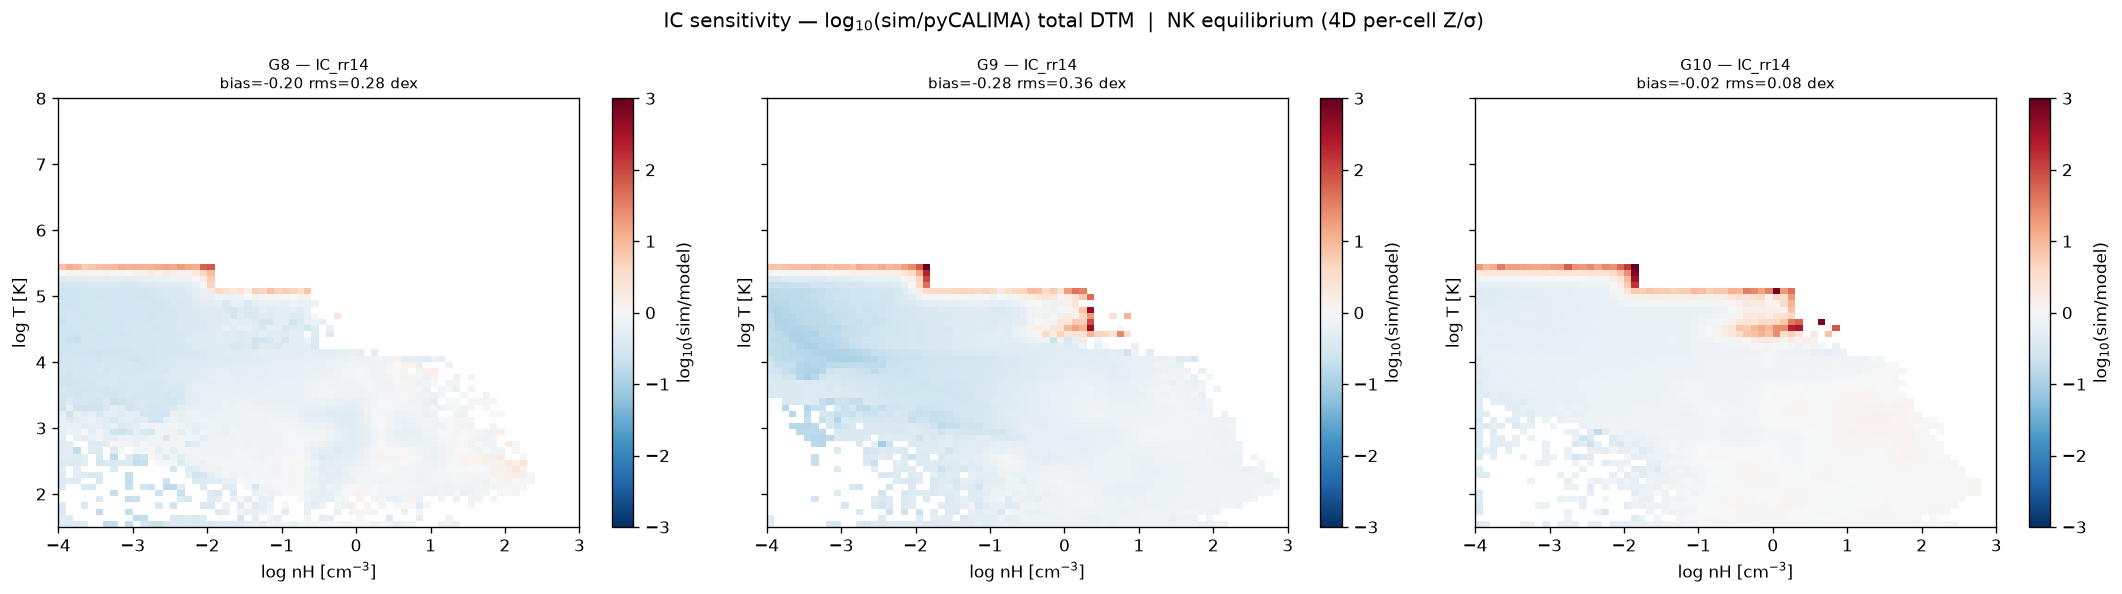

Saved IC_sensitivity.png


In [13]:
IC_LABELS = IC_4D           # ['IC_rr14']

fig, axes = plt.subplots(len(IC_LABELS), len(SIMS),
                          figsize=(6*len(SIMS), 5*len(IC_LABELS)),
                          sharex=True, sharey=True, squeeze=False)

for row, ic_lbl in enumerate(IC_LABELS):
    for col, sim in enumerate(SIMS):
        ax      = axes[row, col]
        DTM_eq  = get_DTM_eq(sim, ic_lbl)
        tot_eq  = np.nansum(DTM_eq, axis=1)
        tot_s   = np.nansum(sim['DTM_bins'], axis=1)
        ok = (tot_eq>0) & (tot_s>0) & np.isfinite(tot_eq)
        lr = np.full(len(sim['T']), np.nan)
        lr[ok] = np.log10(tot_s[ok]) - np.log10(tot_eq[ok])
        m  = ok & np.isfinite(lr)
        res = compute_bias(sim['DTM_bins'], DTM_eq, sim['masses'], sim['T'], sim['nH'])
        b, r, _ = res['TOTAL']
        im = phase_map(ax, sim['nH'][m], sim['T'][m], lr[m], sim['masses'][m],
                       f"{sim['tag']} — {ic_lbl}\nbias={b:+.2f} rms={r:.2f} dex",
                       cmap='RdBu_r', vmin=-3, vmax=3, log=False)
        plt.colorbar(im, ax=ax, label='log$_{10}$(sim/model)')

fig.suptitle('IC sensitivity — log$_{10}$(sim/pyCALIMA) total DTM  |  NK equilibrium (4D per-cell Z/σ)', fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'IC_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved IC_sensitivity.png')


## 8. Integration Time Sweep

Bias as a function of t_end ∈ {50, 100, 200, 400} Myr (IC_sim, RK4).
Tests whether the bias is transient (converges to 0 with time) or systematic.

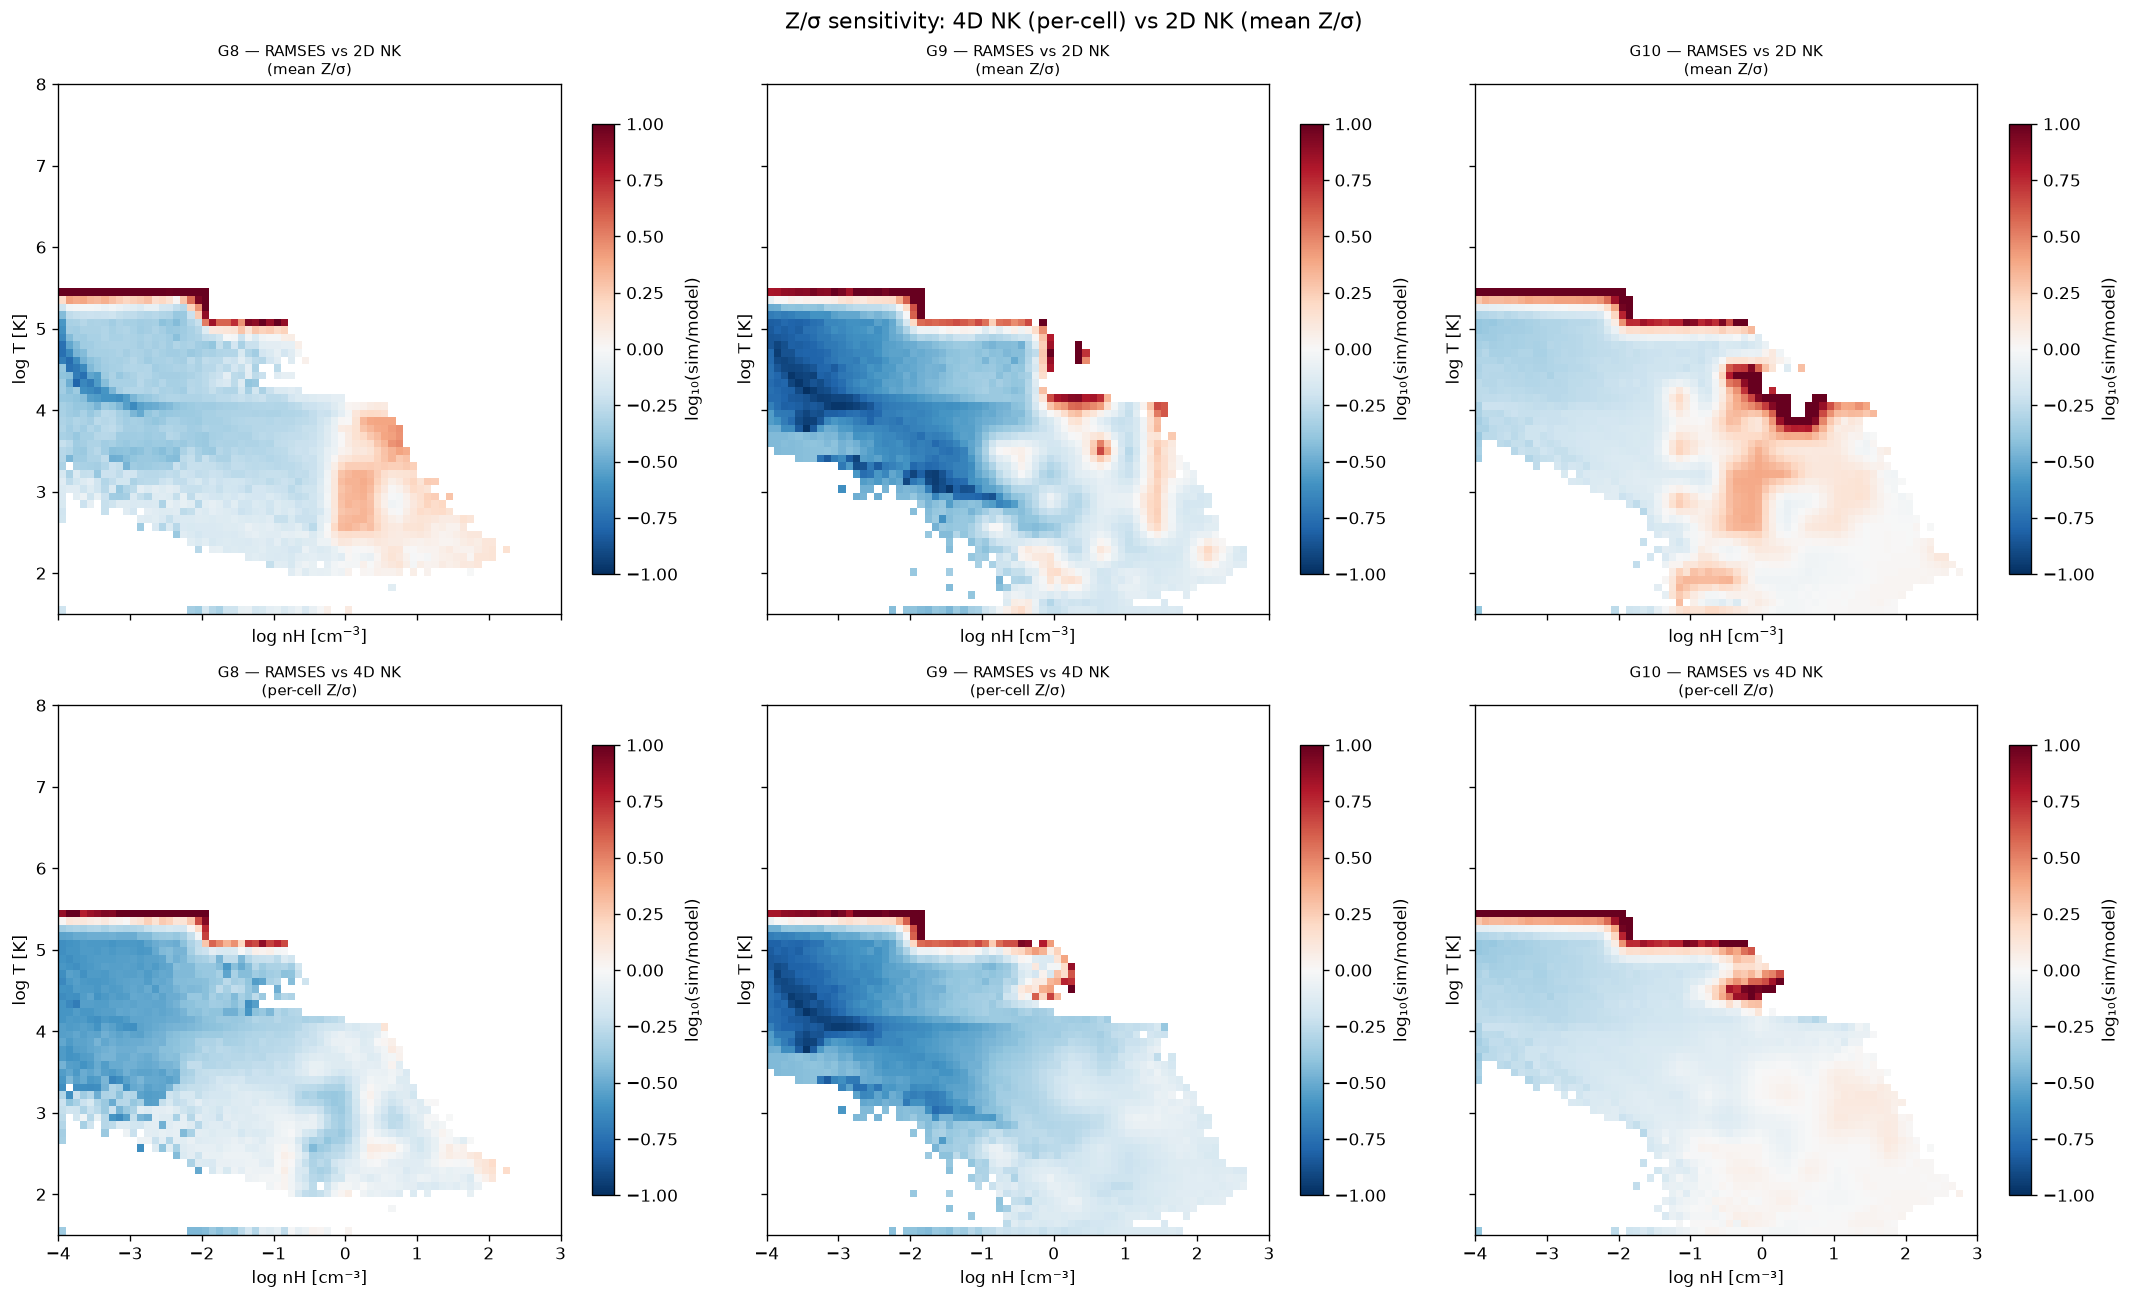

Saved zsig_sensitivity.png


In [14]:
# § Z/sigma sensitivity: compare 4D NK (per-cell Z,σ) vs 2D NK (mean Z,σ)
# This shows what fraction of the RAMSES-vs-model bias comes from using
# the correct per-cell metallicity and velocity dispersion.

fig, axes = plt.subplots(2, len(SIMS), figsize=(6*len(SIMS), 11),
                          sharex=True, sharey=True)
fig.suptitle('Z/σ sensitivity: 4D NK (per-cell) vs 2D NK (mean Z/σ)', fontsize=13)

for col, sim in enumerate(SIMS):
    # 4D NK with per-cell Z and sigma
    DTM_4d  = get_DTM_eq(sim, 'IC_rr14')
    # 2D NK at mean Z and sigma
    DTM_2d  = interp_grid(sim['GRID_2D_NK']['DTM_grid'], sim['T'], sim['nH'])

    tot_4d = np.nansum(DTM_4d, axis=1)
    tot_2d = np.nansum(DTM_2d, axis=1)
    tot_s  = np.nansum(sim['DTM_bins'], axis=1)

    # Row 0: RAMSES vs 2D NK (mean Z/sigma)
    # No sigma mask here: sigma=0 cells have real RAMSES DTM and a valid
    # mean-sigma 2D NK prediction; excluding them would lose diffuse nH<0.1 gas.
    DTM_MIN = 1e-4
    ok0 = (tot_2d > DTM_MIN) & (tot_s > 0) & np.isfinite(tot_2d)
    lr0 = np.full(len(sim['T']), np.nan)
    lr0[ok0] = np.log10(tot_s[ok0]) - np.log10(tot_2d[ok0])
    m0 = ok0 & np.isfinite(lr0)
    im0 = phase_map(axes[0, col], sim['nH'][m0], sim['T'][m0], lr0[m0],
                    sim['masses'][m0],
                    f"{sim['tag']} — RAMSES vs 2D NK\n(mean Z/σ)",
                    cmap='RdBu_r', vmin=-1, vmax=1, log=False, min_count=5)
    plt.colorbar(im0, ax=axes[0, col], label='log₁₀(sim/model)', shrink=0.85)

    # Row 1: RAMSES vs 4D NK (per-cell Z/sigma)
    ok1 = (tot_4d > DTM_MIN) & (tot_s > 0) & np.isfinite(tot_4d)
    lr1 = np.full(len(sim['T']), np.nan)
    lr1[ok1] = np.log10(tot_s[ok1]) - np.log10(tot_4d[ok1])
    m1 = ok1 & np.isfinite(lr1)
    im1 = phase_map(axes[1, col], sim['nH'][m1], sim['T'][m1], lr1[m1],
                    sim['masses'][m1],
                    f"{sim['tag']} — RAMSES vs 4D NK\n(per-cell Z/σ)",
                    cmap='RdBu_r', vmin=-1, vmax=1, log=False, min_count=5)
    plt.colorbar(im1, ax=axes[1, col], label='log₁₀(sim/model)', shrink=0.85)

axes[0,0].set_ylabel('log T [K]')
axes[1,0].set_ylabel('log T [K]')
for col in range(len(SIMS)):
    axes[1,col].set_xlabel('log nH [cm⁻³]')

fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'zsig_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved zsig_sensitivity.png')


## 9. RK4 400 Myr vs Newton–Krylov Equilibrium

Compare time-integrated (RK4) and steady-state (NK) solutions.
Third column: RK4/NK ratio to isolate transient vs equilibrium effects.

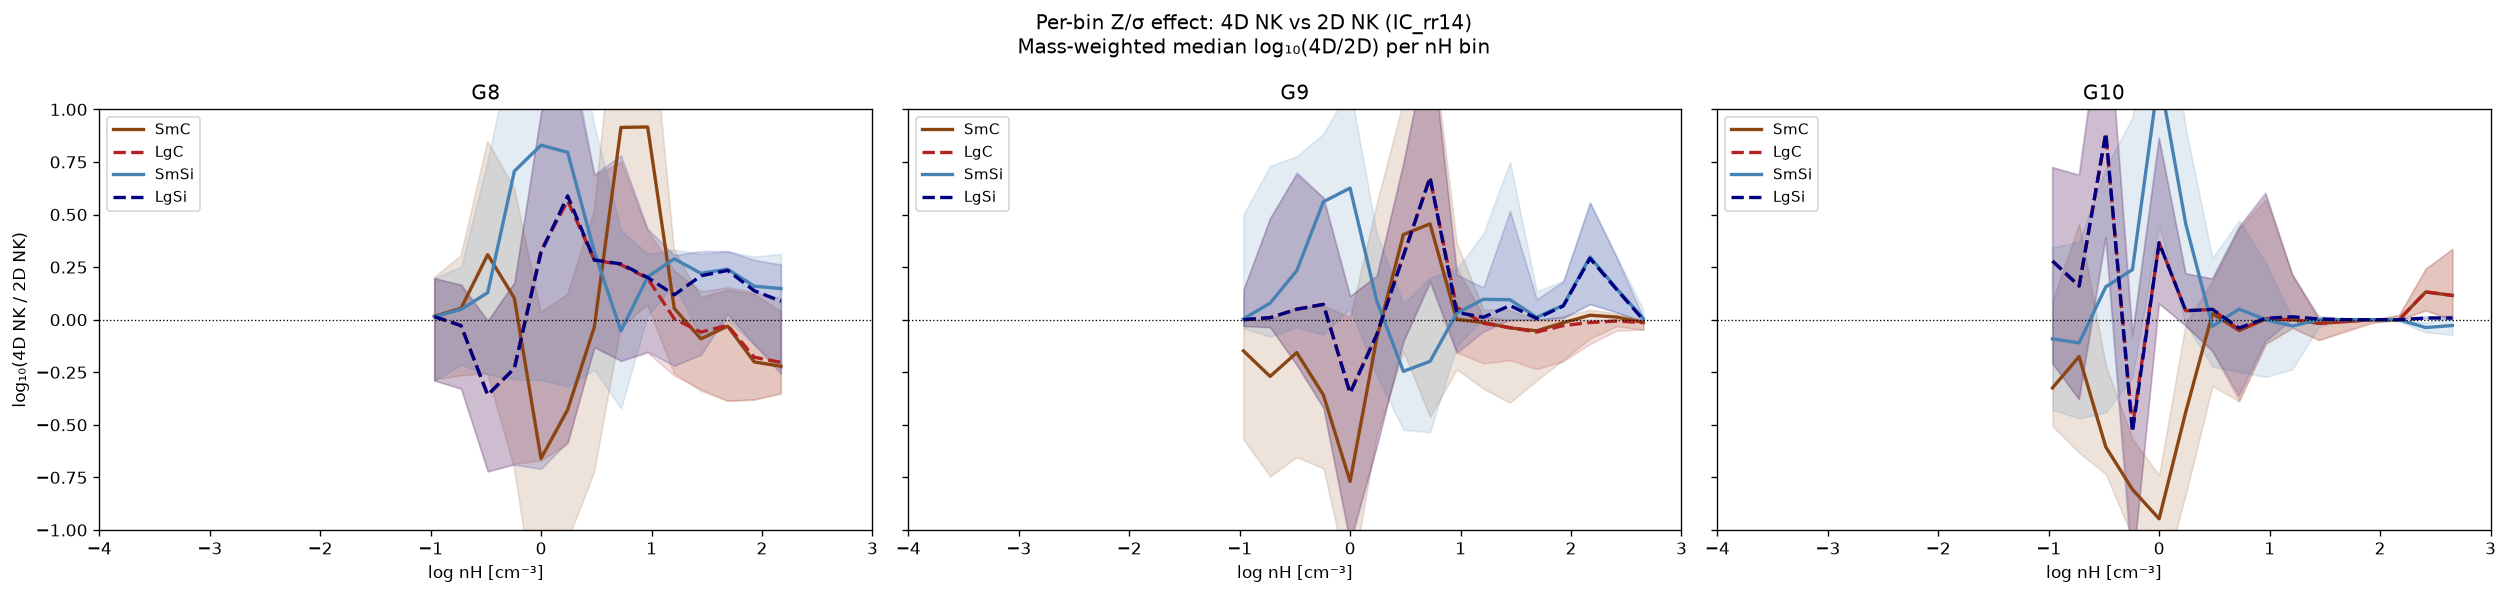

Saved perbin_zsig_effect.png


In [15]:
# § Per-bin Z/sigma effect: 4D NK vs 2D NK — shown as 1D profile vs nH
# Mass-weighted median of log10(4D/2D) per nH bin, with 16th-84th pct shading.
# A 2D (T,nH) or (Z,nH) phase map shows vertical stripes here because the
# equilibrium is T-independent in the accretion-dominated regime (DTM = DTM_max).
# The 1D nH profile directly shows where per-cell Z/σ matters most.

nH_BINS = np.logspace(NH_LO, NH_HI, 30)
nH_CENTS = 0.5 * (nH_BINS[:-1] + nH_BINS[1:])

BIN_COLORS = ['saddlebrown', 'firebrick', 'steelblue', 'navy']
BIN_LS     = ['-', '--', '-', '--']

fig, axes = plt.subplots(1, len(SIMS), figsize=(7*len(SIMS), 5), sharey=True)
fig.suptitle('Per-bin Z/σ effect: 4D NK vs 2D NK (IC_rr14)\nMass-weighted median log₁₀(4D/2D) per nH bin', fontsize=12)

for col, sim in enumerate(SIMS):
    ax = axes[col]
    DTM_4d = get_DTM_eq(sim, 'IC_rr14')
    DTM_2d = interp_grid(sim['GRID_2D_NK']['DTM_grid'], sim['T'], sim['nH'])
    sig_ok = sim['sig'] >= SIG_GRID[0]

    for k, (bname, bshort, clr, ls) in enumerate(zip(BIN_NAMES, BIN_SHORT, BIN_COLORS, BIN_LS)):
        DTM_MIN = 1e-4
        ok = (DTM_4d[:,k] > DTM_MIN) & (DTM_2d[:,k] > DTM_MIN) & np.isfinite(DTM_4d[:,k]) & sig_ok
        lr = np.full(len(sim['T']), np.nan)
        lr[ok] = np.log10(DTM_4d[ok, k]) - np.log10(DTM_2d[ok, k])

        med  = np.full(len(nH_CENTS), np.nan)
        lo16 = np.full(len(nH_CENTS), np.nan)
        hi84 = np.full(len(nH_CENTS), np.nan)
        for i in range(len(nH_CENTS)):
            m = ok & (sim['nH'] >= nH_BINS[i]) & (sim['nH'] < nH_BINS[i+1])
            if m.sum() >= 10:
                w   = sim['masses'][m]
                v   = lr[m]
                # weighted percentiles via sorting
                idx = np.argsort(v)
                cw  = np.cumsum(w[idx]) / w.sum()
                med[i]  = np.interp(0.50, cw, v[idx])
                lo16[i] = np.interp(0.16, cw, v[idx])
                hi84[i] = np.interp(0.84, cw, v[idx])

        valid = np.isfinite(med)
        x = np.log10(nH_CENTS[valid])
        ax.plot(x, med[valid], color=clr, ls=ls, lw=2, label=bshort)
        ax.fill_between(x, lo16[valid], hi84[valid], color=clr, alpha=0.15)

    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xlabel('log nH [cm⁻³]')
    ax.set_title(sim['tag'])
    ax.set_xlim(NH_LO, NH_HI)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel('log₁₀(4D NK / 2D NK)')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'perbin_zsig_effect.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved perbin_zsig_effect.png')


## 10. Bias Summary — G8 vs G10 Side-by-Side

Bar chart comparing per-bin and total DTM bias for both simulations,
for both RK4 (400 Myr) and NK (equilibrium) solvers with IC_sim.

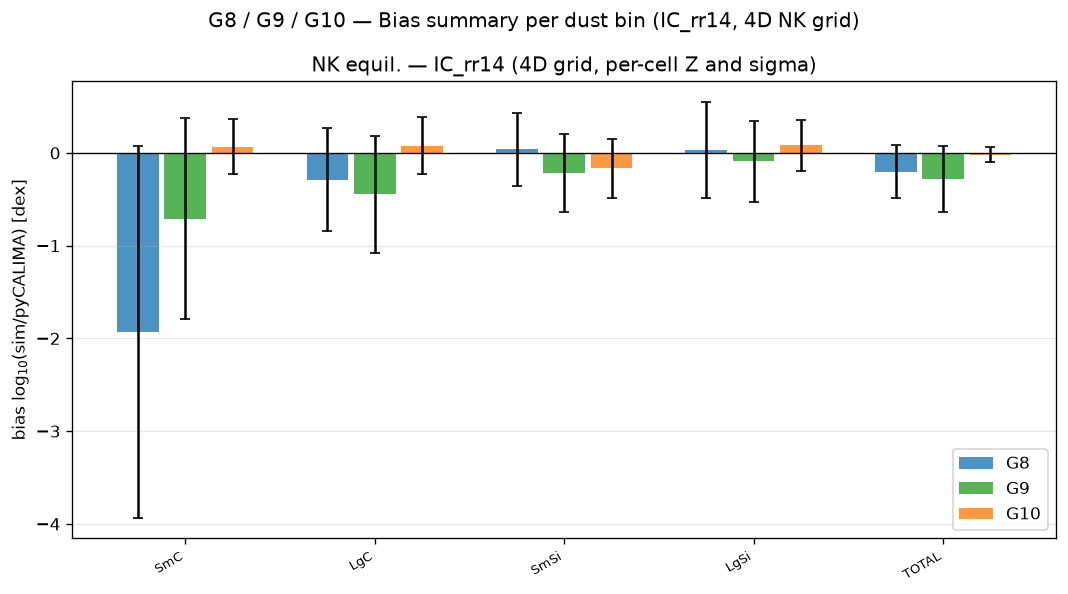

Sim    IC           Solver   Bin               bias     rms       N
---------------------------------------------------------------------------


G8     IC_rr14      NK equil. TOTAL           -0.201   0.285  810822


G9     IC_rr14      NK equil. TOTAL           -0.278   0.355 2595217


G10    IC_rr14      NK equil. TOTAL           -0.018   0.077 4030075


In [16]:
IC_LABELS = IC_4D           # ['IC_rr14']
fig, ax   = plt.subplots(1, 1, figsize=(9, 5))
labels = BIN_SHORT + ['TOTAL']
keys   = BIN_NAMES + ['TOTAL']
x = np.arange(len(labels))
colors = ['C0', 'C2', 'C1']   # G8, G9, G10

for col, (ic_lbl, ttl) in enumerate([('IC_rr14','NK equil.')]):
    # ax already defined above (single panel)
    for i, (sim, clr) in enumerate(zip(SIMS, colors)):
        DTM_eq = get_DTM_eq(sim, ic_lbl)
        res    = compute_bias(sim['DTM_bins'], DTM_eq, sim['masses'], sim['T'], sim['nH'])
        b_vals = [res[k][0] for k in keys]
        r_vals = [res[k][1] for k in keys]
        offset = -0.25 + i * 0.25
        ax.bar(x+offset, b_vals, 0.22, yerr=r_vals, capsize=3,
               label=sim['tag'], color=clr, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('bias log$_{10}$(sim/pyCALIMA) [dex]')
    solver_lbl = ttl
    ax.set_title(f'{solver_lbl} — {ic_lbl} (4D grid, per-cell Z and sigma)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('G8 / G9 / G10 — Bias summary per dust bin (IC_rr14, 4D NK grid)', fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'bias_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# Text summary table
print('='*75)
print(f'{"Sim":<6} {"IC":<12} {"Solver":<8} {"Bin":<14} {"bias":>7} {"rms":>7} {"N":>7}')
print('-'*75)
for sim in SIMS:
    for ic_lbl in IC_LABELS:
        DTM_eq = get_DTM_eq(sim, ic_lbl)
        res = compute_bias(sim['DTM_bins'], DTM_eq, sim['masses'], sim['T'], sim['nH'])
        b, r, n = res['TOTAL']
        print(f"{sim['tag']:<6} {ic_lbl:<12} {'NK equil.':<8} {'TOTAL':<14} {b:+7.3f} {r:7.3f} {n:7d}")
print('='*75)


## 11. Bias Projection Maps

Spatially resolved log₁₀(RAMSES / NK equilibrium) projected along z. Mass-weighted 2D histogram using per-cell (x, y) positions — equivalent to a yt density-weighted projection.

  G8: bias fields registered
  G9: bias fields registered
  G10: bias fields registered


/Users/currodri/.pyenv/versions/3.12.8/envs/calima/lib/python3.12/site-packages/unyt/array.py:1900: RuntimeWarning: invalid value encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)
/var/folders/58/96fm5s6j59n5snmm10l22tnc0000gp/T/ipykernel_53662/3781945292.py:43: RuntimeWarning: divide by zero encountered in divide
  res = np.where(ok, np.log10(DTM_s/tot_e), 0.0).reshape(orig)


/var/folders/58/96fm5s6j59n5snmm10l22tnc0000gp/T/ipykernel_53662/3781945292.py:55: RuntimeWarning: divide by zero encountered in log10
  res = np.where(ok, np.log10(fs_s/fs_e), 0.0).reshape(orig)


/var/folders/58/96fm5s6j59n5snmm10l22tnc0000gp/T/ipykernel_53662/3781945292.py:67: RuntimeWarning: divide by zero encountered in divide
  res = np.where(ok, np.log10(fc_s/fc_e), 0.0).reshape(orig)


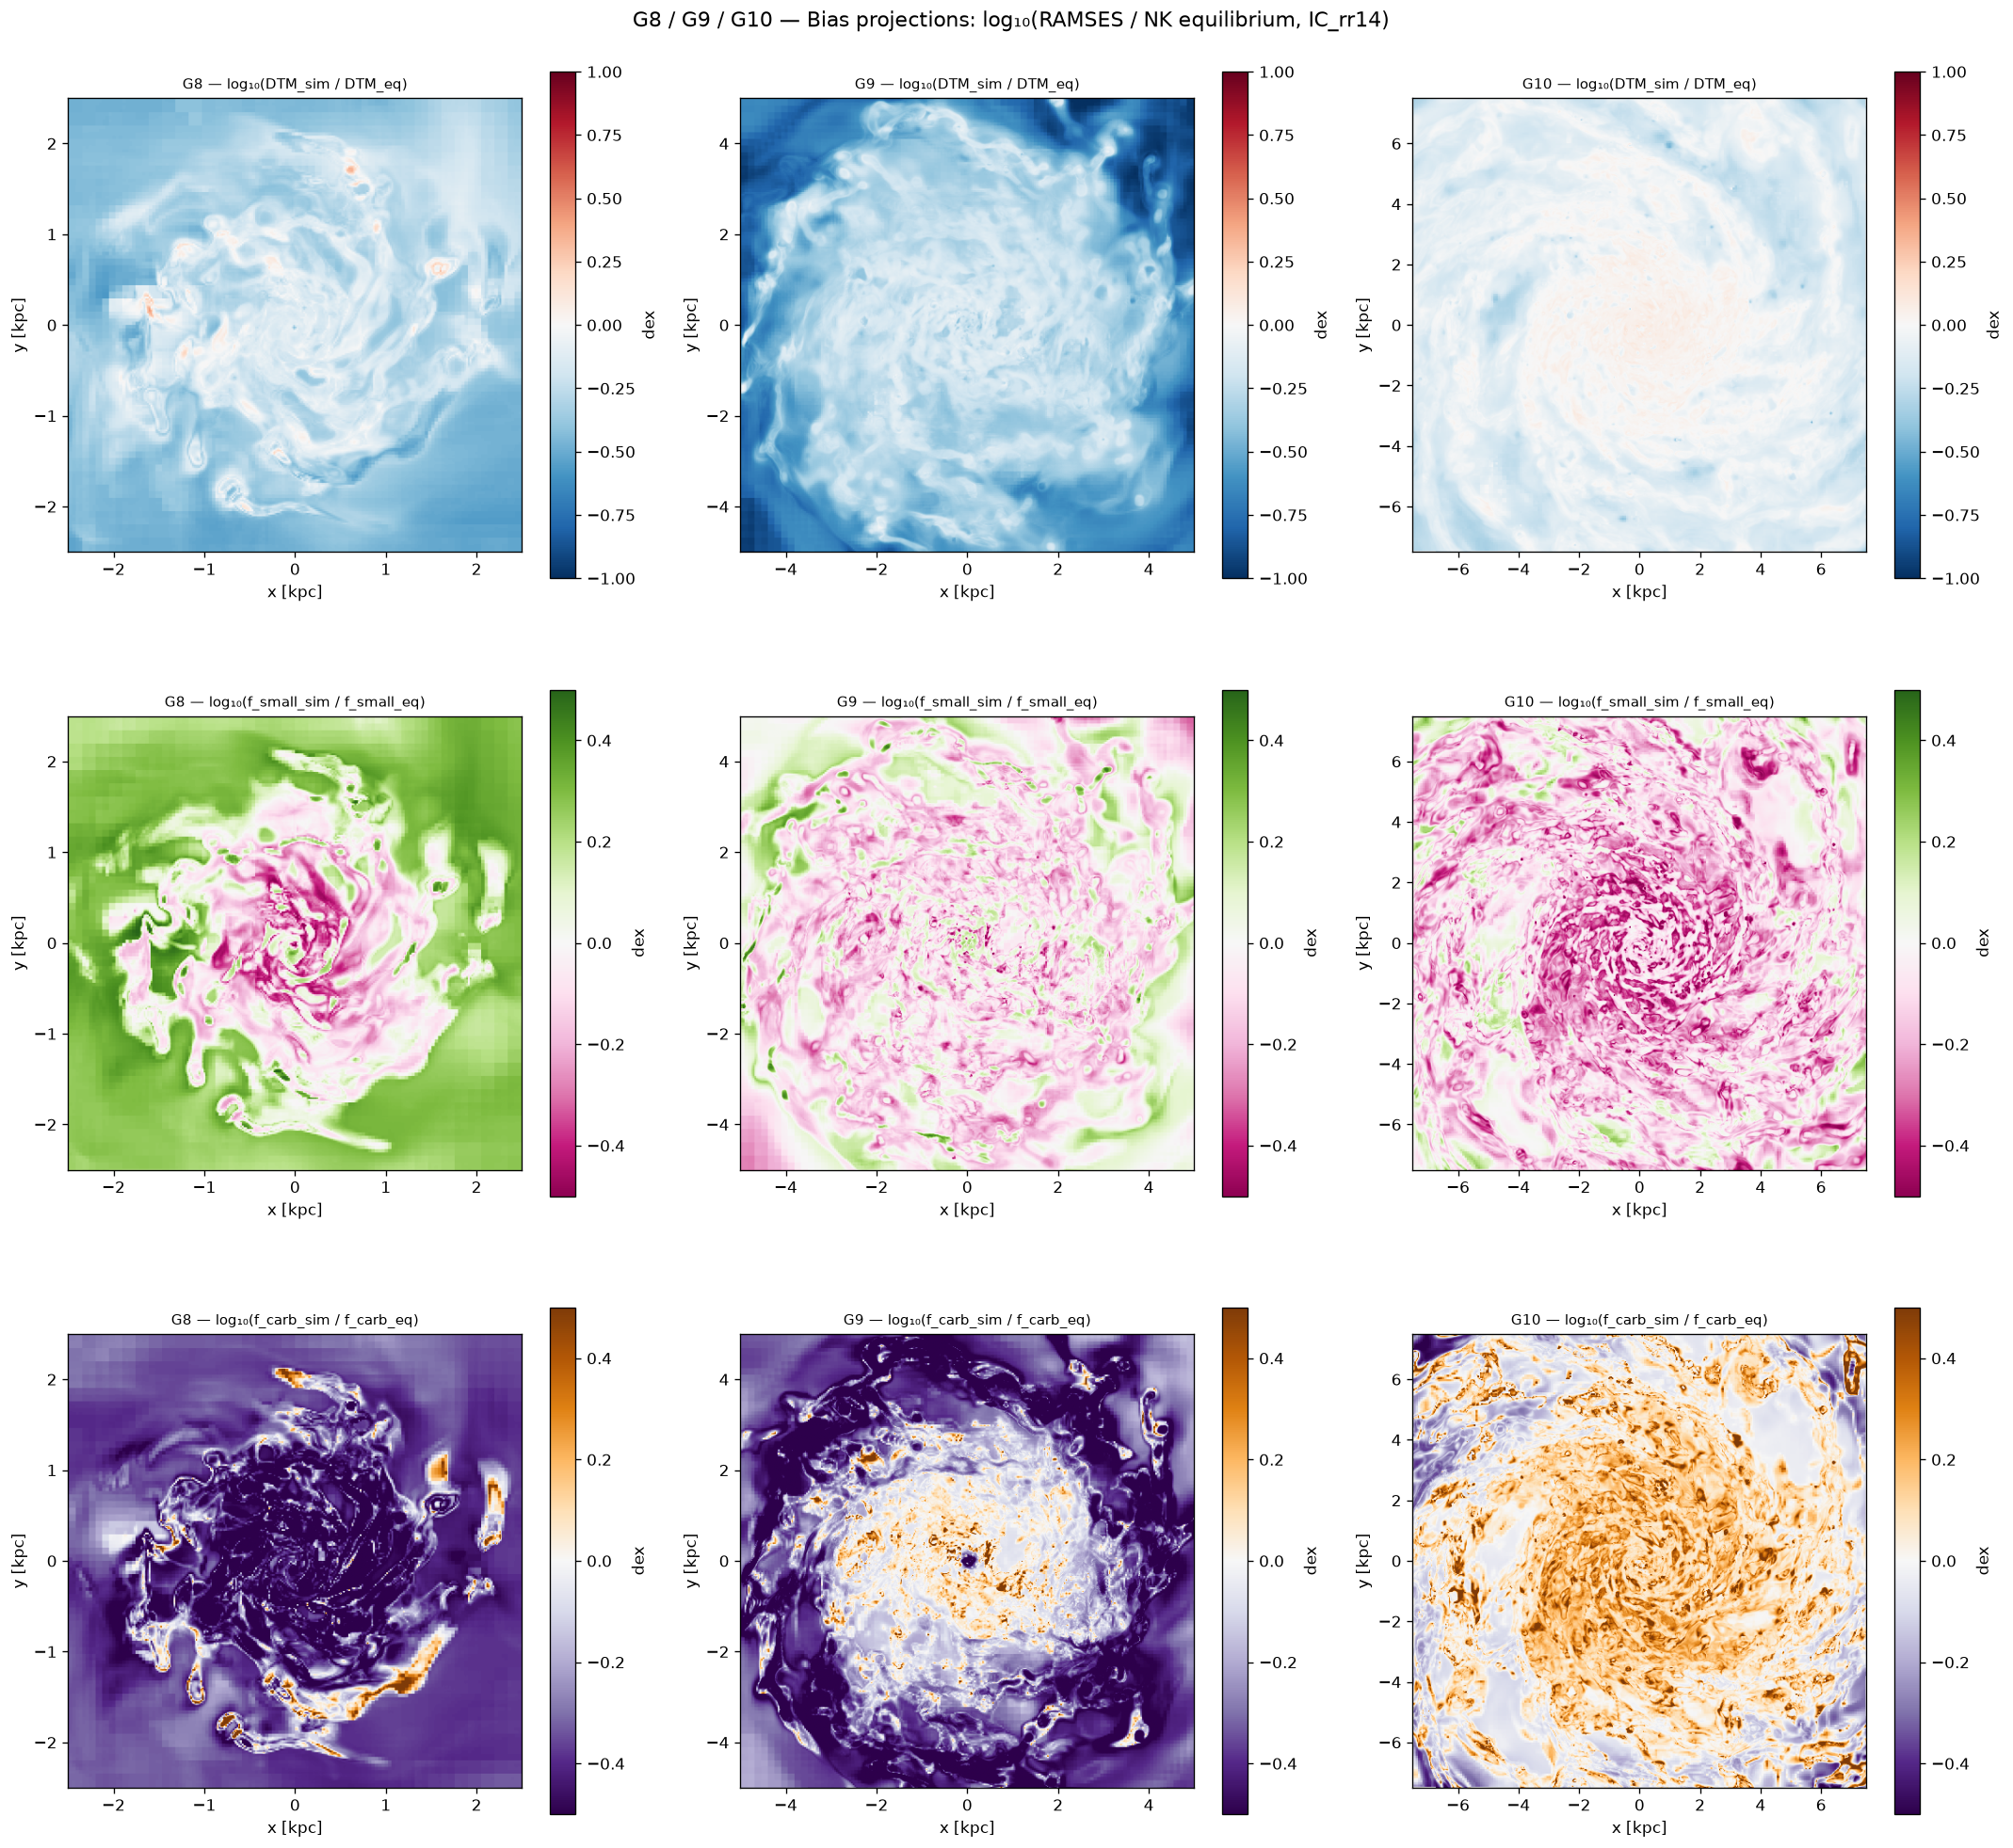

Saved bias_projections.png


In [17]:
# § Bias projection maps: log10(RAMSES / NK equilibrium, IC_rr14)
# Uses yt ds.proj() for proper AMR-aware projections — same pipeline as cell 9.
# NK-equilibrium fields are registered as yt derived fields via closures.
# Note: log10(DTG_sim/DTG_eq) = log10(DTM_sim/DTM_eq) (Z cancels), so 3 rows.

from scipy.interpolate import RegularGridInterpolator as RGI

def add_bias_fields(sim, ic_label='IC_rr14'):
    """Register log10(RAMSES/NK) derived fields on sim's yt dataset."""
    ds      = sim['ds']
    grid_4d = sim['GRID_4D'][ic_label]['DTM_4d']   # (nT, nNH, nZ, nSig, 4)
    axes_4d = (np.log10(T_GRID), np.log10(NH_GRID),
               np.log10(Z_GRID),  np.log10(SIG_GRID))
    _rgi = [RGI(axes_4d, grid_4d[:,:,:,:,k],
                method='linear', bounds_error=False, fill_value=np.nan)
            for k in range(4)]

    def _interp(data):
        """Return DTM_eq per bin (N, 4), handling any yt chunk shape."""
        orig_shape = data[('gas','T_gas')].v.shape
        T_s   = data[('gas','T_gas')].v.astype(float).ravel()
        nH_s  = data[('gas','nH')].v.astype(float).ravel()
        Z_s   = data[('ramses','Metallicity')].v.astype(float).ravel()
        sig_s = np.clip(data[('gas','sigma_turb_kms')].v.astype(float).ravel(), 0.1, None)
        pts = np.column_stack([
            np.log10(np.clip(T_s,   T_GRID[0],   T_GRID[-1])),
            np.log10(np.clip(nH_s,  NH_GRID[0],  NH_GRID[-1])),
            np.log10(np.clip(Z_s,   Z_GRID[0],   Z_GRID[-1])),
            np.log10(np.clip(sig_s, SIG_GRID[0], SIG_GRID[-1])),
        ])
        bins = np.column_stack([r(pts) for r in _rgi])  # (N, 4)
        return bins, orig_shape

    def _bias_DTM(field, data):
        bins_e, orig = _interp(data)
        tot_e = np.nansum(bins_e, axis=1)
        rho   = data[('gas','density')].to('g/cm**3').v.ravel()
        mf    = data[('ramses','Metallicity')].v.astype(float).ravel()
        dust  = sum(data[('gas',f'rho_d{k+1}')].to('g/cm**3').v.ravel() for k in range(4))
        with np.errstate(invalid='ignore', divide='ignore'):
            DTM_s = np.where(mf*rho > 0, dust/(mf*rho), np.nan)
        ok = (DTM_s > 1e-6) & (tot_e > 1e-6) & np.isfinite(DTM_s) & np.isfinite(tot_e)
        res = np.where(ok, np.log10(DTM_s/tot_e), 0.0).reshape(orig)
        return data.ds.arr(res, 'dimensionless')

    def _bias_f_small(field, data):
        bins_e, orig = _interp(data)
        tot_e = np.nansum(bins_e, axis=1)
        d = [data[('gas',f'rho_d{k+1}')].to('g/cm**3').v.ravel() for k in range(4)]
        tot_s = sum(d)
        with np.errstate(invalid='ignore', divide='ignore'):
            fs_s = np.where(tot_s > 0, (d[0]+d[2])/tot_s, np.nan)
            fs_e = np.where(tot_e > 0, (bins_e[:,0]+bins_e[:,2])/tot_e, np.nan)
        ok = (fs_s > 0) & (fs_e > 0) & np.isfinite(fs_s) & np.isfinite(fs_e)
        res = np.where(ok, np.log10(fs_s/fs_e), 0.0).reshape(orig)
        return data.ds.arr(res, 'dimensionless')

    def _bias_f_carb(field, data):
        bins_e, orig = _interp(data)
        tot_e = np.nansum(bins_e, axis=1)
        d = [data[('gas',f'rho_d{k+1}')].to('g/cm**3').v.ravel() for k in range(4)]
        tot_s = sum(d)
        with np.errstate(invalid='ignore', divide='ignore'):
            fc_s = np.where(tot_s > 0, (d[0]+d[1])/tot_s, np.nan)
            fc_e = np.where(tot_e > 0, (bins_e[:,0]+bins_e[:,1])/tot_e, np.nan)
        ok = (fc_s > 0) & (fc_e > 0) & np.isfinite(fc_s) & np.isfinite(fc_e)
        res = np.where(ok, np.log10(fc_s/fc_e), 0.0).reshape(orig)
        return data.ds.arr(res, 'dimensionless')

    for fname, fn in [('bias_DTM', _bias_DTM),
                      ('bias_f_small', _bias_f_small),
                      ('bias_f_carb',  _bias_f_carb)]:
        ds.add_field(('gas', fname), units='dimensionless', sampling_type='cell',
                     force_override=True, function=fn)

for sim in SIMS:
    add_bias_fields(sim)
    print(f"  {sim['tag']}: bias fields registered")

BIAS_PANELS = [
    ('bias_DTM',     'log₁₀(DTM_sim / DTM_eq)',           'RdBu_r',  -1.0, 1.0),
    ('bias_f_small', 'log₁₀(f_small_sim / f_small_eq)',   'PiYG',    -0.5, 0.5),
    ('bias_f_carb',  'log₁₀(f_carb_sim / f_carb_eq)',     'PuOr_r',  -0.5, 0.5),
]

fig, axes = plt.subplots(3, len(SIMS), figsize=(6*len(SIMS), 17))
fig.suptitle('G8 / G9 / G10 — Bias projections: log₁₀(RAMSES / NK equilibrium, IC_rr14)',
             fontsize=13)

for row, (fname, ttl, cmap, vmin, vmax) in enumerate(BIAS_PANELS):
    for col, sim in enumerate(SIMS):
        ax     = axes[row, col]
        yt_fld = ('gas', fname)
        prj = sim['ds'].proj(yt_fld, 'z', weight_field=('gas','density'),
                             data_source=sim['region'])
        frb  = prj.to_frb((sim['width_kpc'], 'kpc'), 512, center=sim['center'])
        img  = np.array(frb[yt_fld])
        half = sim['width_kpc'] / 2.0
        im = ax.imshow(img.T, origin='lower',
                       extent=[-half, half, -half, half],
                       cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
        ax.set_xlabel('x [kpc]');  ax.set_ylabel('y [kpc]')
        ax.set_aspect('equal')
        ax.set_title(f"{sim['tag']} — {ttl}", fontsize=9)
        plt.colorbar(im, ax=ax, label='dex', shrink=0.85)

fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'bias_projections.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved bias_projections.png')
